# Variable-Rate Reduced-Order Model for Reservoir Pressure Dynamics

**Extends the single-schedule ROM to arbitrary variable-rate histories via Duhamel superposition.**

---

## Theoretical Foundation

For a single-phase, slightly-compressible reservoir the diffusivity equation is **linear in pressure**:

$$\frac{\partial p}{\partial t} = \frac{k}{\phi\mu c_t}\nabla^2 p$$

This linearity guarantees the **superposition principle (Duhamel's theorem)**: the bottomhole
pressure response to any arbitrary rate history $q(t)$ can be expressed as a convolution of the
unit-step drawdown response $h(t)$ [psi/(STB/d)] and the rate change history:

$$\Delta p_{wf}(t) = \int_0^t h(t-\tau)\,\frac{dq}{d\tau}\,d\tau$$

For a **piecewise-constant** schedule with $N$ steps at times $t_0=0 < t_1 < \cdots < t_{N-1}$:

$$\boxed{\Delta p_{wf}(t) = \sum_{j=0}^{N-1}\frac{\Delta q_j}{q_\mathrm{ref}}\,h(t-t_j^+), \qquad h(t<0)\equiv 0}$$

where $\Delta q_j = q_j - q_{j-1}$ (negative for a rate decrease or shut-in).

The **ROM state-space model** is *exactly* a continuous-time LTI system:

$$\dot{\hat{x}} = \hat{A}\hat{x} + \hat{B}\,u(t), \qquad y = \hat{C}\hat{x} + \hat{D}\,u(t)$$

so Duhamel superposition holds **exactly** — it provides a rigorous linearity check.

### Rate Transient Analysis (RTA)

For variable-rate data the **Material Balance Time** (Blasingame *et al.*, 1991) collapses the
response onto the equivalent constant-rate drawdown curve:

$$t_e = \frac{N_p(t)}{q(t)}, \qquad N_p(t) = \int_0^t q(\tau)\,d\tau$$

The **Rate-Normalized Pressure** and its log-log derivative are:

$$\mathrm{RNP}(t_e) = \frac{\Delta p_{wf}}{q}, \qquad \mathrm{RNP}'(t_e) = \frac{d\,\mathrm{RNP}}{d\ln t_e}$$

In the MTR, both RNP and RNP$'$ become constant on the log-log plot — the hallmark of
infinite-acting radial flow, regardless of the rate schedule.

### Horner Build-up

After production at rate $q$ for equivalent time $t_p$ then shut-in for $\Delta t$:

$$p_{ws}(\Delta t) = p_i - m\log_{10}\!\left(\frac{t_p+\Delta t}{\Delta t}\right), \qquad m = \frac{162.6\,q\mu B_o}{kh}$$


## 0. Imports, Paths and Global Configuration

In [2]:
import json, pickle, shutil, warnings, time
from pathlib import Path


import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import LogLocator, LogFormatter
from scipy.special import expi
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from matplotlib.ticker import NullLocator
import matplotlib.patheffects as pe

warnings.filterwarnings("ignore")

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})

C1, C2, C3, C4  = "#1a5e9e", "#0d6e56", "#9b2a1a", "#b07318"
C_MRST, C_ROM   = "#2C5F8A", "#C0392B"
C_DUH, C_RNP    = "#6A0572", "#025E73"   # colours for new modules

# ── Directory layout ──────────────────────────────────────────────────────
TRAINING_DIR = Path("../data/01_training")
VAL_DIR      = Path("../data/02_validation")
ROM_DIR      = Path("../rom_vrate")
FIG_DIR      = Path("../figures_vrate");  FIG_DIR.mkdir(parents=True, exist_ok=True)
def sf(n): plt.savefig(FIG_DIR/n,dpi=300,bbox_inches='tight'); print(f'  {n}')
for _d in ["basis", "operators", "interpolants", "results"]:
    (ROM_DIR / _d).mkdir(parents=True, exist_ok=True)

# ── Reservoir constants (field units) ────────────────────────────────────
P_INIT  = 4500.0        # psia
NX, NY  = 50, 50
N_CELLS = NX * NY
N_STEPS = 350
T_START, T_END = 0.001, 5000.0
PHI    = 0.18
CT     = 1.2e-5         # psi⁻¹
MU_CP  = 1.2            # cp
BO     = 1.15           # RB/STB
H_FT   = 150.0          # ft
RW_FT  = 0.35           # ft
C_WBS  = 0.003          # bbl/psi
DX_FT  = 30 * 3.28084   # ft
RE_FT  = (NX * 30 / 2) * 3.28084
WC_IDX = (NY//2 - 1)*NX + (NX//2 - 1)   # 1224  (Python 0-indexed)

K_GRID = [10, 20, 50, 100, 200, 300]
S_GRID = [0, 1, 2, 4, 6, 8]
SCHEDS = list(range(1, 8))

print(f"Training data : {TRAINING_DIR.resolve()}")
print(f"ROM output    : {ROM_DIR.resolve()}")
print(f"Well cell idx : {WC_IDX}  (0-indexed)")
print(f"RE_FT         : {RE_FT:.1f} ft")


Training data : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
ROM output    : F:\Niloy Deb\Part Two\reservoir_rom\rom_vrate
Well cell idx : 1224  (0-indexed)
RE_FT         : 2460.6 ft


## 1. Rate Schedule Inventory and Training Data Validation

All 7 MRST schedules are catalogued from the saved `params.json` files.
Variable-rate schedules (schedules with $>1$ control period) are the main focus of this notebook.


In [3]:
# ── I/O helpers ───────────────────────────────────────────────────────────
def load_mat(filepath, key):
    try:
        return sio.loadmat(str(filepath), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(filepath), "r") as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr

def load_well_data(case_dir):
    wd  = case_dir / "well_data.mat"
    bhp = load_mat(wd, "bhp_psia").ravel()
    t   = load_mat(wd, "time_hr").ravel()
    q   = load_mat(wd, "rate_STBd").ravel()
    dp  = load_mat(wd, "delta_p_psi").ravel()
    with open(case_dir / "params.json") as f:
        pm = json.load(f)
    return bhp, t, q, dp, pm

def get_schedule_shape(pm):
    """Return (rates_STBd array, t_change_hr array) from params dict."""
    rates = np.atleast_1d(pm["rates_STBd"])
    t_ch  = np.atleast_1d(pm.get("t_change_hr", []))
    return rates, t_ch

# ── Physics screening (identical to primary notebook) ─────────────────────
def n_log_steps(ta, tb, t_start=T_START, t_end=T_END, n=N_STEPS):
    ta, tb = max(ta, t_start), min(tb, t_end)
    if tb <= ta: return 0
    return int(n * np.log10(tb/ta) / np.log10(t_end/t_start))

def physics_screen(k, s):
    kh    = k * H_FT
    t_wbs = 170000.0 * C_WBS * MU_CP * np.exp(0.14*s) / kh
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k) * 0.1
    n_wbs = n_log_steps(T_START, t_wbs)
    n_mtr = n_log_steps(t_wbs, t_pss)
    n_bdf = n_log_steps(t_pss, T_END)
    if t_wbs >= T_END:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "t_WBS >= T_end"
    if t_wbs >= t_pss:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "no MTR"
    if n_mtr < 15:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, f"n_MTR={n_mtr}<15"
    return True, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "VALID"

VALID_PAIRS = [(k,s) for k in K_GRID for s in S_GRID
               if physics_screen(k,s)[0]]
print(f"Valid (k,S) training pairs : {len(VALID_PAIRS)} / {len(K_GRID)*len(S_GRID)}")


Valid (k,S) training pairs : 36 / 36


In [4]:
# ── Catalogue all 7 schedules from params.json ────────────────────────────
sched_rows = []
for sid in SCHEDS:
    # Read from any valid (k,S) pair — schedule metadata is identical across k,S
    for k, s in VALID_PAIRS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        if (cd / "params.json").exists():
            try:
                _, t, q, _, pm = load_well_data(cd)
                rates, t_ch   = get_schedule_shape(pm)
                n_ctrl         = len(rates)
                label          = pm.get("schedule_label", f"sched{sid}")
                rate_str       = " → ".join(f"{int(r)}" for r in rates)
                t_ch_str       = ", ".join(f"{v:.0f}" for v in t_ch) if len(t_ch) > 0 else "—"
                sched_rows.append(dict(
                    sched_id=sid, label=label, n_controls=n_ctrl,
                    rates_STBd=rate_str, t_changes_hr=t_ch_str,
                    is_variable=(n_ctrl > 1)))
            except Exception:
                pass
            break

df_sched = pd.DataFrame(sched_rows).drop_duplicates("sched_id").set_index("sched_id")
print("Rate Schedule Inventory")
print("=" * 70)
print(df_sched.to_string())
VARIABLE_SCHEDS = df_sched[df_sched["is_variable"]].index.tolist()
SINGLE_SCHEDS   = df_sched[~df_sched["is_variable"]].index.tolist()
print(f"\nSingle-rate schedules  : {SINGLE_SCHEDS}")
print(f"Variable-rate schedules: {VARIABLE_SCHEDS}")


Rate Schedule Inventory
                  label  n_controls        rates_STBd t_changes_hr  is_variable
sched_id                                                                       
1                 q800c           1               800            —        False
2                 q400c           1               400            —        False
3                q1200c           1              1200            —        False
4            q1000to500           2        1000 → 500         1000         True
5             q400to900           2         400 → 900         1000         True
6           q800buildup           2           800 → 0         2500         True
7         q600_1000_300           3  600 → 1000 → 300   1667, 3333         True

Single-rate schedules  : [1, 2, 3]
Variable-rate schedules: [4, 5, 6, 7]


  fig01_rate_schedules_grid.pdf


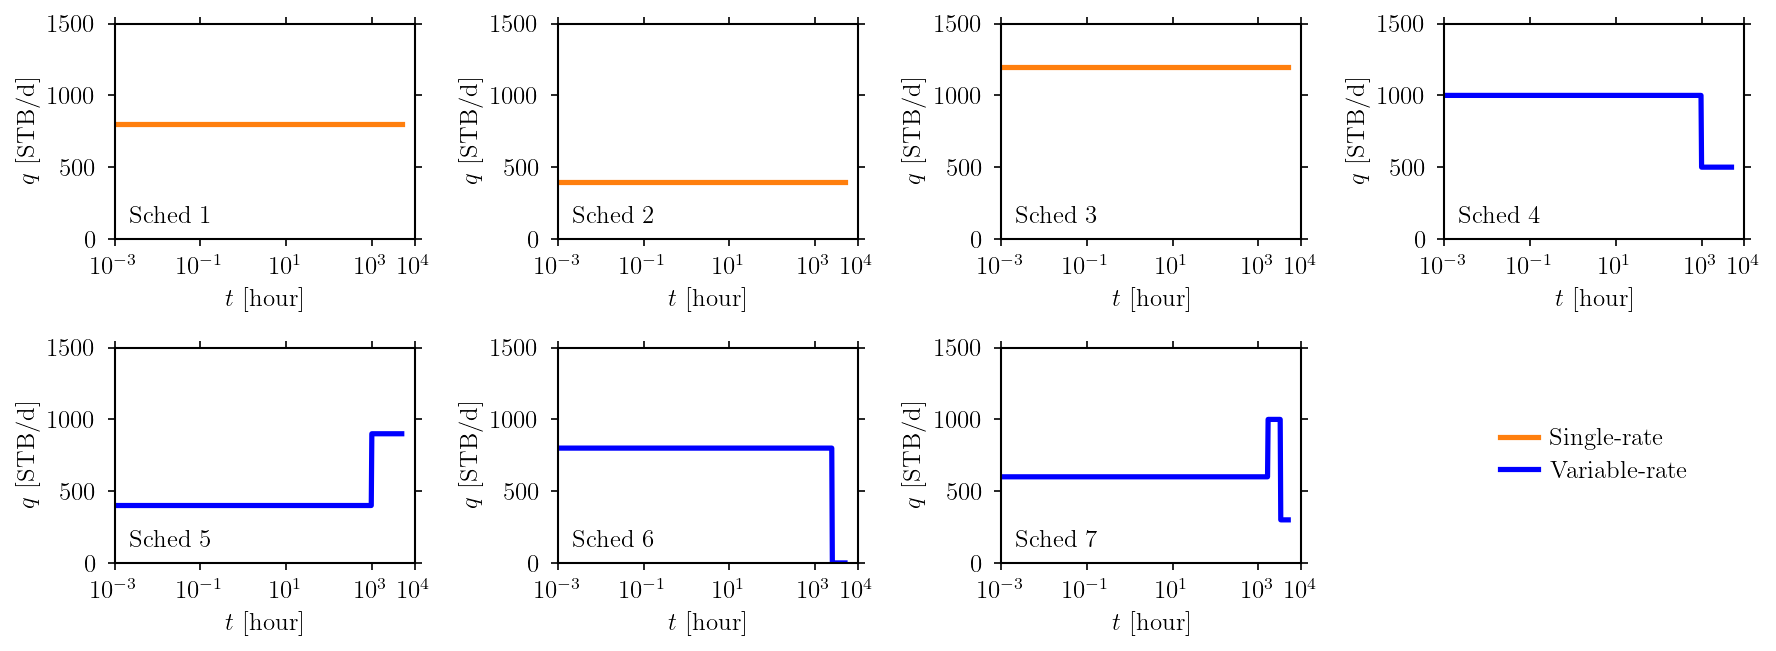

In [5]:

# 2 rows, 4 columns (8 panels total for 7 schedules)
fig, axes = plt.subplots(2, 4, figsize=(12, 4.5))
axes_flat = axes.ravel()
T_HIST = np.logspace(np.log10(T_START), np.log10(T_END), 500)

custom_ylims_rate = [(0, 1500), (0, 1500), (0, 1500), (0, 1500), (0, 1500), (0, 1500), (0, 1500)]

for si, sid in enumerate(SCHEDS):
    ax = axes_flat[si]
    for k, s in VALID_PAIRS[:1]:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            _, t, q, _, pm = load_well_data(cd)
            rates, t_ch = get_schedule_shape(pm)
            
            # Build step function
            q_hist = np.full(len(T_HIST), float(rates[0]))
            for j, tc in enumerate(t_ch):
                q_hist[T_HIST >= tc] = float(rates[j+1]) if (j+1)<len(rates) else 0.0
            
            # Use distinct colors for Single vs Variable rate schedules
            col = 'blue' if len(rates) > 1 else 'C1'
            ax.semilogx(T_HIST, q_hist, color=col, lw=2.5)
            
           # lbl = pm.get("schedule_label", f"Schedule {sid}")
           # ax.set_title(f"Sched {sid}: {lbl}", fontsize=12, fontweight="normal")

            ax.text(0.05, 0.05, f"Sched {sid}", 
                    transform=ax.transAxes, 
                    fontsize=12, 
                    verticalalignment="bottom")
            
            # Minimal Formatting
            ax.set_xlabel("$t$ [hour]", fontsize=12)
            ax.set_ylabel("$q$ [STB/d]", fontsize=12)
            ax.set_xlim([0.001, 1e4])
            ax.set_xticks([1e-3, 1e-1, 1e1, 1e3, 1e4])
            ax.set_ylim(custom_ylims_rate[si])
        
            
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())
            ax.tick_params(labelsize=12)
            
        except Exception:
            ax.text(0.5, 0.5, "Missing", ha="center", va="center", transform=ax.transAxes, fontsize=12)

# Hide the 8th empty subplot
axes_flat[-1].axis("off")

# Create a clean global legend in the empty 8th panel
leg = [Line2D([0],[0], color='C1', lw=2.5, label="Single-rate"),
       Line2D([0],[0], color='blue', lw=2.5, label="Variable-rate")]
axes_flat[-1].legend(handles=leg, loc="center", fontsize=12, frameon=False)

plt.tight_layout()
sf("fig01_rate_schedules_grid.pdf")
plt.show()

In [6]:
# ── File integrity check across all valid (k,S,sched) triples ─────────────
issues = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        for fname in ["snapshots_psia.mat", "well_data.mat", "params.json"]:
            if not (cd/fname).exists():
                issues.append((name, f"{fname} missing"))
                continue
        try:
            X = load_mat(cd/"snapshots_psia.mat","X_psia")
            if X.shape[0] != N_CELLS:
                issues.append((name, f"wrong rows {X.shape[0]}"))
            if not np.isfinite(X).all():
                issues.append((name, "NaN/Inf"))
        except Exception as e:
            issues.append((name, str(e)))

total = len(VALID_PAIRS) * len(SCHEDS)
print(f"Checked : {total}  (k,S,sched) combinations")
if issues:
    print(f"Issues  : {len(issues)}")
    for nm, msg in issues[:15]: print(f"  {nm}: {msg}")
else:
    print("All files present, correct shape, finite values.")


Checked : 252  (k,S,sched) combinations
All files present, correct shape, finite values.


## 2. POD Basis Construction

All valid (k, S) pairs **and all 7 schedules** contribute to the snapshot matrix.
Temporal weighting ($w_j = \sqrt{\Delta t_j}$) de-emphasises the densely-sampled
early-time region so that each flow regime contributes equitably to the basis.

$$Z = \bigl[\sqrt{\Delta t}\,\odot\,(X - p_i)\bigr]_{\text{all cases}}$$

SVD: $Z = U \Sigma V^T$.  Basis $V_n = U_{:,1:n}$.


In [7]:
snap_cols, cases_pod = [], []

for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        try:
            X  = load_mat(cd/"snapshots_psia.mat","X_psia")
            dX = X - P_INIT
            _, t, _, _, _ = load_well_data(cd)
            dt = np.diff(t, prepend=0.0); dt[0] = t[0]
            w  = np.sqrt(dt); w /= (w.mean() + 1e-12)
            snap_cols.append(dX * w)
            cases_pod.append(name)
        except FileNotFoundError:
            print(f"  Missing: {name}")

Z = np.hstack(snap_cols)
print(f"Snapshot matrix Z : {Z.shape}  ({Z.nbytes/1e6:.0f} MB)")
print(f"Cases (k,S,sched) : {len(cases_pod)}")
print("Computing SVD ...")
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f"Done.  σ₁={sigma[0]:.2f}  σ_last={sigma[-1]:.2e}")


Snapshot matrix Z : (2500, 88200)  (1764 MB)
Cases (k,S,sched) : 252
Computing SVD ...
Done.  σ₁=2245963.70  σ_last=2.04e-11


  fig02_pod_convergence_rigorous.pdf


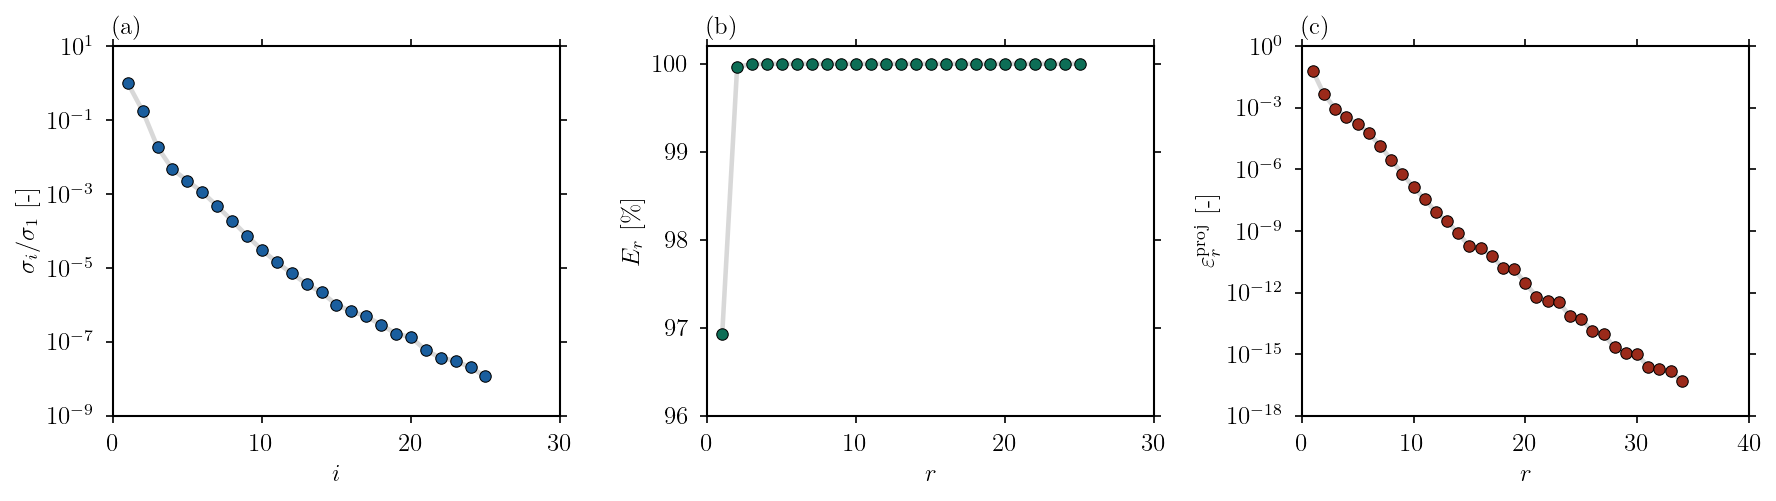

Modes for 99.9% energy      : 2
Modes for proj error < 1e-4 : 6


In [8]:
# ── Mode count selection ──────────────────────────────────────────────────
cum_energy  = np.cumsum(sigma**2) / np.sum(sigma**2)
n_try_range = np.arange(1, min(35, len(sigma)+1))
proj_errors = []

for n_try in n_try_range:
    Vt  = U[:, :n_try]
    err = 0.0
    file_count = 0
    
    # Rigorous Evaluation: Loop over ALL validation pairs and ALL schedules
    for k, s in VALID_PAIRS:
        for sid in SCHEDS:
            try:
                X  = load_mat(TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
                              / "snapshots_psia.mat", "X_psia") - P_INIT
                Xr = Vt @ (Vt.T @ X)
                err += np.linalg.norm(X-Xr, "fro")**2 / (np.linalg.norm(X, "fro")**2 + 1e-12)
                file_count += 1
            except FileNotFoundError:
                pass
                
    # Divide the total error by the actual number of loaded schedule/pair combinations
    proj_errors.append(err / max(file_count, 1))

proj_errors = np.array(proj_errors)
N_SHOW      = min(25, len(sigma))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# --- Plot (a): Singular Value Decay ---
ax0 = axes[0]
ax0.semilogy(range(1, N_SHOW+1), sigma[:N_SHOW]/sigma[0], 'o', color=C1, ms=5.5, mec='k', mew=0.5, zorder=3)
ax0.semilogy(range(1, N_SHOW+1), sigma[:N_SHOW]/sigma[0], color='gray', alpha=0.3, lw=2.2, zorder=1)

ax0.set_title('(a)', loc='left', fontweight='normal')
ax0.set_xlabel('$i$', fontsize=12)
ax0.set_ylabel(r'$\sigma_i / \sigma_1$ [-]', fontsize=12)
ax0.set_xlim([0, 30])
ax0.set_ylim([1e-9, 10])
ax0.tick_params(labelsize=12)

# --- Plot (b): Cumulative Energy ---
ax1 = axes[1]
ax1.plot(range(1, N_SHOW+1), cum_energy[:N_SHOW]*100, 'o', color=C2, ms=5.5, mec='k', mew=0.5, zorder=3)
ax1.plot(range(1, N_SHOW+1), cum_energy[:N_SHOW]*100, color='gray', alpha=0.3, lw=2.2, zorder=1)

ax1.set_title('(b)', loc='left', fontweight='normal')
ax1.set_xlabel('$r$', fontsize=12)
ax1.set_ylabel(r'$E_r \ [\%]$', fontsize=12)
ax1.set_xlim([0, 30])
ax1.set_ylim([96, 100.2])
ax1.tick_params(labelsize=12)

# --- Plot (c): Mean Projection Error ---
ax2 = axes[2]
ax2.semilogy(n_try_range, proj_errors, 'o', color=C3, ms=5.5, mec='k', mew=0.5, zorder=3)
ax2.semilogy(n_try_range, proj_errors, color='gray', alpha=0.3, lw=2.2, zorder=1)

ax2.set_title('(c)', loc='left', fontweight='normal')
ax2.set_xlabel('$r$', fontsize=12)
ax2.set_ylabel(r'$\varepsilon_r^\mathrm{proj}$ [-]', fontsize=12)
ax2.set_xlim([0, 40])
ax2.set_ylim([1e-18, 1])
ax2.tick_params(labelsize=12)

plt.tight_layout()
sf("fig02_pod_convergence_rigorous.pdf")
plt.show()

n99  = int(np.argmax(cum_energy >= 0.999)) + 1
n1e4 = int(np.argmax(proj_errors < 1e-4))  + 1 if np.any(proj_errors < 1e-4) else "not reached"
print(f"Modes for 99.9% energy      : {n99}")
print(f"Modes for proj error < 1e-4 : {n1e4}")

In [9]:
N_MODES = 15
Vn      = U[:, :N_MODES]

# Projection errors across ALL schedules
per_err = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        try:
            X  = load_mat(TRAINING_DIR/f"k{k:03d}_s{s:02d}_sched{sid}"/"snapshots_psia.mat","X_psia") - P_INIT
            Xr = Vn @ (Vn.T @ X)
            per_err.append(np.linalg.norm(X-Xr,"fro")**2 / (np.linalg.norm(X,"fro")**2+1e-12))
        except FileNotFoundError:
            pass

print(f"N_MODES selected : {N_MODES}")
print(f"Basis shape Vn   : {Vn.shape}")
print(f"Orthogonality    : ||VnT·Vn − I||_inf = {np.abs(Vn.T@Vn - np.eye(N_MODES)).max():.2e}")
print(f"Proj error (mean): {np.mean(per_err):.2e}   max: {np.max(per_err):.2e}")

np.save(ROM_DIR/"basis"/"Vn.npy",    Vn)
np.save(ROM_DIR/"basis"/"sigma.npy", sigma)
print(f"Basis saved → {ROM_DIR/'basis'}/")


N_MODES selected : 15
Basis shape Vn   : (2500, 15)
Orthogonality    : ||VnT·Vn − I||_inf = 1.11e-15
Proj error (mean): 1.75e-10   max: 1.36e-09
Basis saved → ..\rom_vrate\basis/


## 3. Operator Inference

The variable-rate schedules provide **richer excitation** of the state space than single-rate
training, improving identifiability of $\hat{A}$ and $\hat{B}$.

Projected state dynamics:
$$\hat{x}(t) = V_n^T\,(p(t) - p_i), \qquad \dot{\hat{x}} \approx \hat{A}\hat{x} + \hat{B}\,q$$

Least-squares formulation (time-weighted):
$$\min_{\hat{A},\hat{B}} \sum_j w_j \left\|\dot{\hat{x}}_j - \hat{A}\hat{x}_j - \hat{B}\,q_j\right\|_2^2 + \lambda\|[\hat{A}\;\hat{B}]\|_F^2$$

The observation pair $(\hat{C}, \hat{D})$:
- $\hat{C}$ is set analytically to the well-cell row of $V_n$.
- $\hat{D}$ absorbs skin + WBS effects via scalar least-squares over the full
  variable-rate excitation history (all schedules simultaneously).


In [10]:
def infer_AB(Vn, X_list, U_list, T_list, t_wbs_list, lam_mult=1.0):
    """
    Infer (Â, B̂) from a collection of state trajectories and rate inputs.
    Time-weighted finite-difference approximation of dx̂/dt.
    """
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []
    for X, u, t, t_wbs in zip(X_list, U_list, T_list, t_wbs_list):
        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T          # [N_t × n_r]
        dt   = np.diff(t, prepend=0.0); dt[0] = t[0]
        R    = np.zeros_like(Xhat)
        R[0] = Xhat[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Xhat[j] - Xhat[j-1]) / dt[j]
        i_s = 1
        w   = np.sqrt(dt[i_s:]); w /= (w.mean() + 1e-12)
        Xhat_rows.append(Xhat[i_s:])
        U_rows.append(u[i_s:].reshape(-1, 1))
        R_rows.append(R[i_s:])
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows);  U_all = np.vstack(U_rows)
    R_all    = np.vstack(R_rows);     W_all = np.concatenate(W_rows)
    D        = np.hstack([Xhat_all, U_all])
    cond_D   = np.linalg.cond(D)
    col_norms= np.linalg.norm(D, axis=0) + 1e-12
    D_w      = (D / col_norms) * W_all[:, None]
    R_w      = R_all * W_all[:, None]
    lam      = 1e-6 * lam_mult * np.trace(D_w.T @ D_w) / D_w.shape[1]
    nc       = D_w.shape[1]
    D_aug    = np.vstack([D_w, np.sqrt(lam)*np.eye(nc)])
    R_aug    = np.vstack([R_w, np.zeros((nc, n_r))])
    OT_sc, *_= np.linalg.lstsq(D_aug, R_aug, rcond=None)
    OT       = OT_sc / col_norms[:, None]
    O        = OT.T
    return O[:, :n_r], O[:, n_r:n_r+1], cond_D


def infer_CD(Vn, X_list, U_list, BHP_list):
    """
    Infer (Ĉ, D̂) from all available rate schedules simultaneously.
    Ĉ is fixed analytically; D̂ absorbs skin via scalar LS.
    """
    C_hat = Vn[WC_IDX, :].reshape(1, -1)
    D_estimates = []
    for X, u, bhp in zip(X_list, U_list, BHP_list):
        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T
        dBHP = (bhp - P_INIT).reshape(-1, 1)
        grid_dp = (C_hat @ Xhat.T).T
        skin_dp = dBHP[1:] - grid_dp[1:]
        u_vec   = u[1:].reshape(-1, 1)
        num = np.vdot(u_vec, skin_dp)
        den = np.vdot(u_vec, u_vec) + 1e-12
        D_estimates.append(num / den)
    return C_hat, np.array([[np.mean(D_estimates)]])

print("Operator inference functions defined.")


Operator inference functions defined.


In [11]:
ops_dir = ROM_DIR / "operators"
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print("Cleared rom_vrate/operators/ — fresh inference\n")

results = []
for k, s in VALID_PAIRS:
    tag     = f"k{k:03d}_s{s:02d}"
    out_dir = ops_dir / tag;  out_dir.mkdir(exist_ok=True)

    X_list, U_list, T_list, BHP_list, t_wbs_list = [], [], [], [], []
    _, t_wbs_an, *_ = physics_screen(k, s)

    for sid in SCHEDS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            X              = load_mat(cd/"snapshots_psia.mat","X_psia")
            bhp, t, q, _, pm = load_well_data(cd)
            t_wbs_case     = float(pm.get("t_wbs_end_hr", t_wbs_an))
            if t_wbs_case >= t[-1]: continue
            X_list.append(X); U_list.append(q); T_list.append(t)
            BHP_list.append(bhp); t_wbs_list.append(t_wbs_case)
        except FileNotFoundError:
            pass

    if not X_list:
        print(f"  SKIP {tag} — no usable schedules"); continue

    # ── Adaptive regularisation loop ─────────────────────────────────────
    max_attempts, lam_mult, stable = 6, 1.0, False
    for attempt in range(max_attempts):
        A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                         t_wbs_list, lam_mult=lam_mult)
        eigv, _ = np.linalg.eig(A_hat)
        if np.all(eigv.real <= 1e-5):
            stable = True; break
        lam_mult *= 5.0

    C_hat, D_hat = infer_CD(Vn, X_list, U_list, BHP_list)

    for nm, arr in [("A_hat",A_hat),("B_hat",B_hat),
                    ("C_hat",C_hat),("D_hat",D_hat)]:
        np.save(out_dir/f"{nm}.npy", arr)

    eig_max = eigv.real.max()
    results.append(dict(tag=tag, k=k, S=s, stable=stable,
                        eig_max=eig_max, cond_D=cond_D,
                        n_scheds=len(X_list), lam_mult=lam_mult))
    flag = "OK" if stable else "UNSTABLE"
    print(f"  {tag}  [{flag}]  λ_max={eig_max:.2e}  cond_D={cond_D:.1e}"
          f"  n_scheds={len(X_list)}")

n_stable = sum(r["stable"] for r in results)
print(f"\nStable : {n_stable}/{len(results)}")


Cleared rom_vrate/operators/ — fresh inference

  k010_s00  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s01  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s02  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s04  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s06  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k010_s08  [OK]  λ_max=1.22e-07  cond_D=4.3e+05  n_scheds=7
  k020_s00  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s01  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s02  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s04  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s06  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k020_s08  [OK]  λ_max=2.87e-07  cond_D=3.5e+05  n_scheds=7
  k050_s00  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s01  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s02  [OK]  λ_max=2.58e-07  cond_D=5.7e+05  n_scheds=7
  k050_s04  [OK]  λ_max=2.58e-07  con

## 4. Operator Interpolation (RBF)

In [12]:
pts_lst = []
A_list2, B_list2, C_list2, D_list2 = [], [], [], []

for rep in results:
    if not rep["stable"]: continue
    A_list2.append(np.load(ops_dir/rep["tag"]/"A_hat.npy"))
    B_list2.append(np.load(ops_dir/rep["tag"]/"B_hat.npy"))
    C_list2.append(np.load(ops_dir/rep["tag"]/"C_hat.npy"))
    D_list2.append(np.load(ops_dir/rep["tag"]/"D_hat.npy"))
    pts_lst.append([np.log10(rep["k"]), rep["S"]])

pts   = np.array(pts_lst)
A_arr = np.array(A_list2)
B_arr = np.array(B_list2)
C_arr = np.array(C_list2)
D_arr = np.array(D_list2)

# Feature scaling → [0, 1]
pts_min = pts.min(axis=0); pts_max = pts.max(axis=0)
pts_rng = pts_max - pts_min; pts_rng[pts_rng == 0] = 1.0
pts_norm = (pts - pts_min) / pts_rng

def build_rbf(arr, pts_n, smoothing=0.0):
    flat = arr.reshape(len(arr), -1)
    ints = [RBFInterpolator(pts_n, flat[:, c],
                            kernel="linear", smoothing=smoothing)
            for c in range(flat.shape[1])]
    return ints, arr.shape[1:]

def eval_op(interps, shape, k_q, s_q):
    pt     = np.array([[np.log10(k_q), float(s_q)]])
    pt_n   = (pt - pts_min) / pts_rng
    return np.array([f(pt_n)[0] for f in interps]).reshape(shape)

M = len(pts)
print(f"Interpolation training points : {M}")
print("Building interpolants ...")
A_interps, A_shape = build_rbf(A_arr, pts_norm, smoothing=0.01)
B_interps, B_shape = build_rbf(B_arr, pts_norm, smoothing=0.01)
C_interps, C_shape = build_rbf(C_arr, pts_norm, smoothing=0.01)
D_interps, D_shape = build_rbf(D_arr, pts_norm, smoothing=0.01)
print("Done.")


Interpolation training points : 30
Building interpolants ...
Done.


Running LOO CV ...
LOO mean error — A: 3.34e+00   D: 4.70e-01
LOO max  error — A: 1.73e+01   D: 4.34e+00


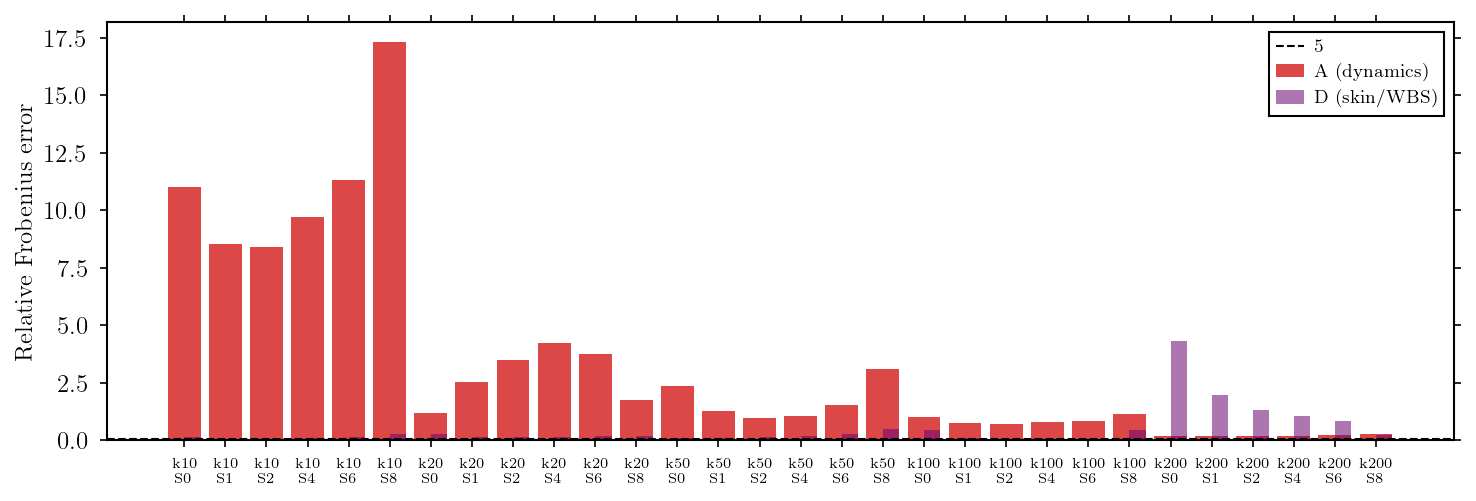

Interpolants saved → ..\rom_vrate\interpolants/


In [13]:
# ── Leave-One-Out cross-validation ────────────────────────────────────────
def loo_errors(arr, pts_n):
    M, flat = len(pts_n), arr.reshape(len(pts_n), -1)
    errs = []
    for held in range(M):
        mask = np.arange(M) != held
        pred_flat = np.zeros(flat.shape[1])
        for c in range(flat.shape[1]):
            rbf = RBFInterpolator(pts_n[mask], flat[mask, c],
                                  kernel="thin_plate_spline", smoothing=0.5)
            pred_flat[c] = rbf(pts_n[[held]])[0]
        actual = arr[held]; pred = pred_flat.reshape(arr.shape[1:])
        errs.append(np.linalg.norm(actual-pred,"fro") /
                    (np.linalg.norm(actual,"fro") + 1e-12))
    return np.array(errs)

print("Running LOO CV ...")
errs_A = loo_errors(A_arr, pts_norm)
errs_D = loo_errors(D_arr, pts_norm)
print(f"LOO mean error — A: {errs_A.mean():.2e}   D: {errs_D.mean():.2e}")
print(f"LOO max  error — A: {errs_A.max():.2e}   D: {errs_D.max():.2e}")

fig, ax = plt.subplots(figsize=(10, 3.5))
cols = ["C1" if e < 0.05 else "C3" for e in errs_A]
ax.bar(range(M), errs_A, color=cols, alpha=0.85, label="A (dynamics)")
ax.bar(range(M), errs_D, color=C_DUH, alpha=0.55, width=0.4,
       align="edge", label="D (skin/WBS)")
ax.axhline(0.05, color="k", ls="--", lw=1, label="5% threshold")
ax.set_xticks(range(M))
ax.set_xticklabels([f"k{int(r['k'])}\nS{int(r['S'])}"
                    for r in results if r["stable"]], fontsize=7)
ax.set_ylabel("Relative Frobenius error"); ax.legend(fontsize=9)
plt.tight_layout()
#plt.savefig(FIG_DIR/"fig03_loo_cv.pdf", bbox_inches="tight")
plt.show()

# Save interpolants
idir = ROM_DIR / "interpolants"; idir.mkdir(exist_ok=True)
for nm, obj in [("A",{"i":A_interps,"s":A_shape}),
                ("B",{"i":B_interps,"s":B_shape}),
                ("C",{"i":C_interps,"s":C_shape}),
                ("D",{"i":D_interps,"s":D_shape})]:
    with open(idir/f"{nm}_interp.pkl","wb") as f: pickle.dump(obj, f)
print(f"Interpolants saved → {idir}/")


## 5. Duhamel Superposition Module

### Theory Recap

For an LTI system the response to any input $q(t)$ is:

$$\Delta p_{wf}(t) = \int_0^t h(t-\tau)\frac{dq}{d\tau}\,d\tau$$

where $h(t)$ is the **unit-step drawdown response** [psi/(STB/d)]: the BHP drawdown when the
well produces at $q=q_{\rm ref}$ starting from quiescent conditions.

For piecewise-constant steps at times $t_0=0<t_1<\cdots<t_{N-1}$:

$$\Delta p_{wf}(t) = \sum_{j=0}^{N-1}\frac{\Delta q_j}{q_{\rm ref}}\,h(t-t_j^+), \qquad \Delta q_j = q_j - q_{j-1}$$

Since the ROM is **exactly** LTI, direct integration and Duhamel superposition must agree to
machine precision — this section provides the rigorous verification.


In [14]:
# ── Core ROM integrator ───────────────────────────────────────────────────
def integrate_rom(A, B, C, D, t_hr, q_vec, n_modes):
    """
    Backward-Euler time integration of the ROM state-space model.
    Returns (Xr, Yr): reduced states and scalar output Δp (psi).
    """
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(n_modes); xk = np.zeros(n_modes)
    Xr = np.zeros((K, n_modes)); Yr = np.zeros(K)
    for j in range(K):
        rhs   = xk + dt[j] * B.ravel() * q_vec[j]
        xk    = np.linalg.solve(In - dt[j]*A, rhs)
        Xr[j] = xk
        Yr[j] = float(C @ xk + D * q_vec[j])
    return Xr, Yr


def query_rom(k_star, s_star, t_hr, q_vec):
    """
    Full ROM evaluation: interpolate operators, integrate, reconstruct field.
    Returns (bhp_psia, p_field, stable_flag).
    """
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    _, Yr = integrate_rom(A, B, C, D, t_hr, q_vec, N_MODES)
    bhp_psia = P_INIT + Yr
    # Full pressure field reconstruction
    Xr, _   = integrate_rom(A, B, C, D, t_hr, q_vec, N_MODES)
    p_field  = P_INIT + (Vn @ Xr.T)
    return bhp_psia, p_field, True


print("query_rom() and integrate_rom() defined.")


query_rom() and integrate_rom() defined.


In [15]:
# ── 5.1  Unit Step Response ───────────────────────────────────────────────
def unit_step_response(k_star, s_star, t_hr, q_ref=500.0):
    """
    Compute h(t) [psi/(STB/d)·q_ref psi] = pressure drawdown for constant
    production at q_ref STB/d starting from quiescent conditions.
    Normalised: h_norm(t) = h(t) / q_ref  [psi per STB/d].
    """
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    q_step = np.full(len(t_hr), q_ref)
    _, h_abs = integrate_rom(A, B, C, D, t_hr, q_step, N_MODES)
    return h_abs, h_abs / q_ref   # (absolute psi, normalised psi/[STB/d])


# ── 5.2  Duhamel Superposition Predictor ─────────────────────────────────
def duhamel_predict(k_star, s_star, t_hr, q_vec, q_ref=500.0):
    """
    Predict Δp_wf(t) for arbitrary piecewise-constant q(t) via Duhamel
    superposition on the ROM unit-step response.

    Algorithm
    ---------
    1. Compute h(t) once via unit_step_response().
    2. Detect rate-change events (indices where |Δq| > threshold).
    3. For each event j at time t_j with rate-step Δq_j:
           contribution(i) = (Δq_j / q_ref) × h(t_i − t_j)  for t_i ≥ t_j
    4. Sum all contributions to get total Δp(t).
    """
    h_abs, h_norm = unit_step_response(k_star, s_star, t_hr, q_ref=q_ref)

    dq = np.diff(q_vec, prepend=0.0)
    change_idx = np.where(np.abs(dq) > 1e-3)[0]

    dp_total = np.zeros_like(t_hr, dtype=float)
    for idx in change_idx:
        t_onset = t_hr[idx] if idx > 0 else 0.0
        dq_j    = dq[idx]
        t_shift = t_hr - t_onset
        valid   = t_shift >= 0.0
        h_shift = np.zeros_like(t_hr)
        h_shift[valid] = np.interp(t_shift[valid], t_hr, h_abs)
        dp_total += (dq_j / q_ref) * h_shift

    bhp_duh = P_INIT + dp_total
    return bhp_duh, dp_total


print("unit_step_response() and duhamel_predict() defined.")


unit_step_response() and duhamel_predict() defined.


  ch7_add_duhamel_linearity.pdf


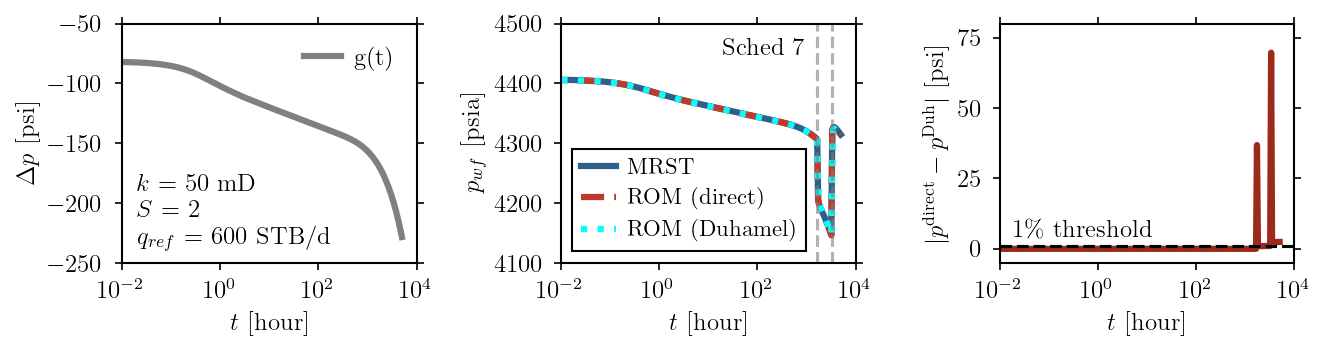

In [27]:
# ── 5.3  Linearity verification: Duhamel == Direct integration ─────────────
k_chk, s_chk = 50, 2
sid_chk       = max(VARIABLE_SCHEDS) if VARIABLE_SCHEDS else 2

cd_chk = TRAINING_DIR / f"k{k_chk:03d}_s{s_chk:02d}_sched{sid_chk}"
bhp_mrst, t_hr, q_v, _, pm = load_well_data(cd_chk)
rates_chk, t_ch_chk = get_schedule_shape(pm)

# Direct ROM integration
bhp_direct, _, _ = query_rom(k_chk, s_chk, t_hr, q_v)

# Duhamel prediction
bhp_duh, dp_duh  = duhamel_predict(k_chk, s_chk, t_hr, q_v, q_ref=float(rates_chk[0]))

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5))

# --- Panel 1: Unit step response ---
t_us = np.logspace(np.log10(t_hr[0]), np.log10(t_hr[-1]), 400)
h_abs_us, h_norm_us = unit_step_response(k_chk, s_chk, t_us, q_ref=float(rates_chk[0]))
axes[0].semilogx(t_us, h_abs_us, color='gray', lw=3, label=f"g(t)")

info_text_a = (f"$k$ = {k_chk} mD\n"
               f"$S$ = {s_chk}\n"
               f"$q_{{ref}}$ = {int(rates_chk[0])} STB/d")
axes[0].text(0.05, 0.05, info_text_a, 
             transform=axes[0].transAxes, 
             fontsize=12, 
             verticalalignment="bottom")

axes[0].set_xlabel("$t$ [hour]", fontsize=12)
axes[0].set_xlim([1e-2, 1e4])
axes[0].set_ylim([-250, -50])
axes[0].set_ylabel(r"$\Delta p$ [psi]", fontsize=12)

# MODIFIED: Added frameon=False to remove the legend box
axes[0].legend(fontsize=12, frameon=False) 

axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_minor_locator(NullLocator())
axes[0].tick_params(labelsize=12)

# --- Panel 2: BHP comparison ---
axes[1].semilogx(t_hr, bhp_mrst,  color=C_MRST,  lw=3, label="MRST")
axes[1].semilogx(t_hr, bhp_direct,color=C_ROM,   lw=3, ls="--", label="ROM (direct)")
axes[1].semilogx(t_hr, bhp_duh,   color='cyan',   lw=3, ls=":",  label="ROM (Duhamel)")

for tc in t_ch_chk:
    axes[1].axvline(tc, color="gray", ls="--", lw=1.5, alpha=0.6)

axes[1].text(0.55, 0.85, f"Sched {sid_chk}", 
             transform=axes[1].transAxes, 
             fontsize=12, 
             verticalalignment="bottom")

axes[1].set_xlabel("$t$ [hour]", fontsize=12)
axes[1].set_ylabel("$p_{wf}$ [psia]", fontsize=12)
axes[1].set_xlim([1e-2, 1e4])
axes[1].set_ylim([4100, 4500])
axes[1].legend(fontsize=11)
axes[1].xaxis.set_minor_locator(NullLocator())
axes[1].yaxis.set_minor_locator(NullLocator())
axes[1].tick_params(labelsize=12)

# --- Panel 3: Error between direct and Duhamel ---
err_psi = np.abs(bhp_direct - bhp_duh)
axes[2].semilogx(t_hr, err_psi, color=C3, lw=3)

# MODIFIED: Removed the label from the axhline
axes[2].axhline(1.0, color="k", ls="--", lw=1.5)

# MODIFIED: Added standard text annotation instead of a legend
axes[2].text(0.05, 0.18, " 1\% threshold", 
             transform=axes[2].transAxes, 
             fontsize=12, 
             verticalalignment="top")

axes[2].set_xlabel("$t$ [hour]", fontsize=12)
axes[2].set_ylabel(r"$|p^{\rm direct} - p^{\rm Duh}|$ [psi]", fontsize=12)

# MODIFIED: Removed the legend command entirely from this panel
#axes[2].legend(fontsize=8) 

axes[2].set_xlim([1e-2, 1e4])
axes[2].set_ylim([-5, 80])

axes[2].xaxis.set_minor_locator(NullLocator())
axes[2].yaxis.set_minor_locator(NullLocator())
axes[2].tick_params(labelsize=12)

plt.tight_layout()
sf("ch7_add_duhamel_linearity.pdf")
plt.show()

## 6. Variable-Rate Validation Against MRST Data

The ROM is evaluated against **all 7 MRST schedules** for a grid of validation parameter points
$(k^*, S^*)$ that were **not in the training set**.

For each case:
1. Load MRST well data (BHP, rate, time).
2. Integrate the ROM using the **same rate history** as MRST.
3. Compute output error and Bourdet diagnostics.


In [17]:
# ── Bourdet derivative (reused from main notebook) ────────────────────────
def bourdet(t_hr, dp, L=0.2):
    ln_t = np.log(t_hr); d = np.full_like(dp, np.nan)
    for i in range(1, len(t_hr)-1):
        il = i-1
        while il > 0  and (ln_t[i]-ln_t[il]) < L: il -= 1
        ir = i+1
        while ir < len(t_hr)-1 and (ln_t[ir]-ln_t[i]) < L: ir += 1
        dl = ln_t[i]-ln_t[il]; dr = ln_t[ir]-ln_t[i]
        if dl > 0 and dr > 0:
            d[i] = ((dp[i]-dp[il])/dl*dr + (dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m = np.isfinite(d) & (d > 0) & (dp > 0)
    return t_hr[m], dp[m], d[m]

print("Bourdet derivative defined.")


Bourdet derivative defined.


In [18]:
# ── 6.1  Cross-schedule validation ───────────────────────────────────────
# Validation (k,S) pairs — outside training grid
VAL_CASES = [(15,2), (30,3), (75,1), (150,4), (250,0)]

val_rows = []
for k_v, s_v in VAL_CASES:
    for sid in SCHEDS:
        # Try validation directory first, then training
        for base in [VAL_DIR, TRAINING_DIR]:
            cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (cd/"well_data.mat").exists(): break
        try:
            bhp_mrst, t_hr, q_v_arr, _, pm = load_well_data(cd)
            rates, t_ch = get_schedule_shape(pm)
            bhp_rom, _, _ = query_rom(k_v, s_v, t_hr, q_v_arr)
            dp_mrst = P_INIT - bhp_mrst
            dp_rom  = P_INIT - bhp_rom
            out_err = (np.linalg.norm(dp_rom - dp_mrst) /
                       (np.linalg.norm(dp_mrst) + 1e-9))
            val_rows.append(dict(k=k_v, S=s_v, sched=sid,
                                 n_ctrls=len(rates),
                                 is_variable=(len(rates)>1),
                                 out_err=out_err))
        except Exception as e:
            val_rows.append(dict(k=k_v, S=s_v, sched=sid,
                                 n_ctrls=0, is_variable=False,
                                 out_err=np.nan))

df_val = pd.DataFrame(val_rows)
print("Validation Output Errors by Case and Schedule")
print("=" * 60)
pivot = df_val.pivot_table(index=["k","S"], columns="sched",
                            values="out_err", aggfunc="mean")
print(pivot.round(3).to_string())
print()
print(f"Overall mean error : {df_val['out_err'].mean():.3e}")
sv = df_val[df_val["is_variable"]]
ss = df_val[~df_val["is_variable"]]
print(f"Variable-rate mean : {sv['out_err'].mean():.3e}")
print(f"Single-rate mean   : {ss['out_err'].mean():.3e}")


Validation Output Errors by Case and Schedule
sched      1      2      3      4      5      6      7
k   S                                                 
15  2  0.041  0.043  0.040  0.043  0.037  0.271  0.041
30  3  0.014  0.015  0.013  0.015  0.012  0.256  0.014
150 4  0.036  0.041  0.034  0.035  0.038  0.216  0.038
250 0  0.126  0.116  0.130  0.154  0.089  0.230  0.116

Overall mean error : 8.050e-02
Variable-rate mean : 1.003e-01
Single-rate mean   : 5.416e-02


  fig05_vrate_validation_comprehensive.pdf


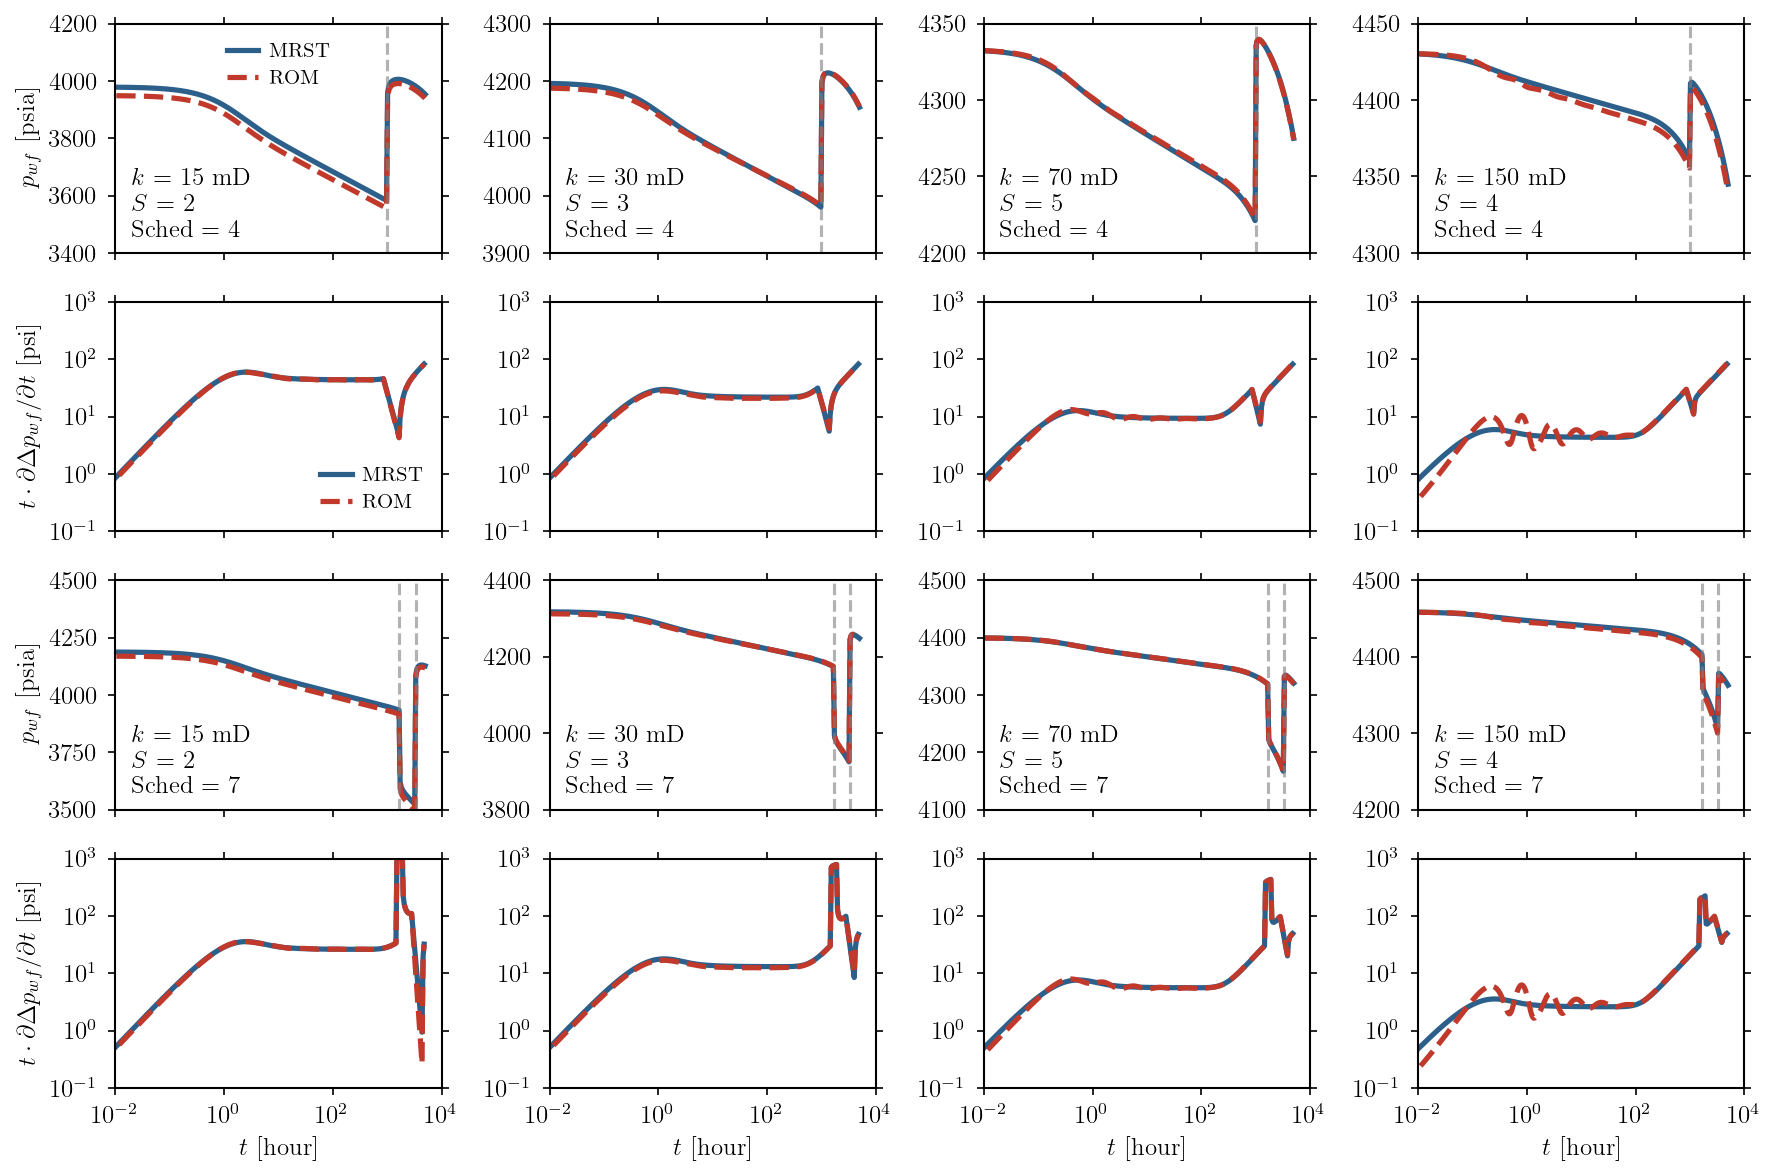

In [19]:

# ── 6.2  Comprehensive Validation:  Validation (Unseen K and s) ─────

# 1. Define explicit cases to plot: (k, S, Label)
selected_cases = [
    (15,   2, "Unseen"),
    (30,   3, "Unseen"),
    (70,   5, "Unseen"),
    (150,  4, "Unseen")
]

# Specifically target variable schedules 4 and 7
schedules_to_plot = [4, 7]

# --- CUSTOM LIMITS CONFIGURATION ---
# Dictionary keyed by Schedule ID. Each contains a list of 4 tuples (for the 4 columns).
custom_ylims_bhp = {
    4: [(3400, 4200), (3900, 4300), (4200, 4350), (4300, 4450)], # Limits for Sched 4
    7: [(3500, 4500), (3800, 4400), (4100, 4500), (4200, 4500)]  # Limits for Sched 7
}

custom_ylims_der = {
    4: [(0.1, 1000), (0.1, 1000), (0.1, 1000), (0.1, 1000)], # Limits for Sched 4
    7: [(0.1, 1000), (0.1, 1000), (0.1, 1000), (0.1, 1000)]  # Limits for Sched 7
}
# -----------------------------------

# Create a 4x4 grid (sharex=True keeps the x-axis labels clean)
fig, axes = plt.subplots(4, 4, figsize=(12, 8), sharex=True)

for col, (k_v, s_v, c_label) in enumerate(selected_cases):
    
    # We will plot two schedules per column (row_offset 0 = Sched 4, 1 = Sched 7)
    for row_offset, sid in enumerate(schedules_to_plot):
        
        # Calculate exactly which rows to place the BHP and Bourdet plots on
        row_bhp = row_offset * 2
        row_der = row_offset * 2 + 1
        
        ax_bhp = axes[row_bhp, col]
        ax_der = axes[row_der, col]
        
        # Find the data file (checking both Validation and Training folders)
        found = False
        for base in [VAL_DIR, TRAINING_DIR]:
            cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (cd / "well_data.mat").exists():
                found = True
                break
        
        # Handle missing data gracefully
        if not found:
            ax_bhp.text(0.5, 0.5, f"Missing\nSched {sid}", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)
            ax_bhp.set_xticks([]); ax_bhp.set_yticks([])
            ax_der.axis('off')
            continue
            
        try:
            # Load Data and Query ROM
            bhp_m, t_hr, q_v_arr, _, pm = load_well_data(cd)
            bhp_r, _, _  = query_rom(k_v, s_v, t_hr, q_v_arr)
            rates, t_ch  = get_schedule_shape(pm)
            dp_m = np.clip(P_INIT - bhp_m, 1e-2, None)
            dp_r = np.clip(P_INIT - bhp_r, 1e-2, None)

            # --- BHP Plot ---
            ax_bhp.semilogx(t_hr, bhp_m, color=C_MRST, lw=2.5, label="MRST")
            ax_bhp.semilogx(t_hr, bhp_r, color=C_ROM,  lw=2.5, ls="--", label="ROM")
            
            # Rate change markers
            for tc in t_ch: 
                ax_bhp.axvline(tc, color="gray", ls="--", lw=1.5, alpha=0.6)
            
            # Replaced Title with Inset Text Box
            info_text = (f"$k$ = {k_v} mD\n"
                         f"$S$ = {s_v}\n"
                         f"Sched = {sid}")
            ax_bhp.text(0.05, 0.05, info_text, 
                        transform=ax_bhp.transAxes, 
                        fontsize=12, 
                        verticalalignment="bottom")
            
            # BHP Formatting
            if col == 0: 
                ax_bhp.set_ylabel("$p_{wf}$ [psia]", fontsize=12)
            
            ax_bhp.set_xlim([0.01, 1e4])
            
            # <-- Applied the custom BHP y-limits dynamically here -->
            ax_bhp.set_ylim(custom_ylims_bhp[sid][col]) 
            
            ax_bhp.xaxis.set_minor_locator(NullLocator())
            ax_bhp.yaxis.set_minor_locator(NullLocator())
            ax_bhp.tick_params(labelsize=12)
            
            # Legend only on the top-left BHP plot
            if col == 0 and row_offset == 0: 
                ax_bhp.legend(fontsize=10, frameon=False)

            # --- Bourdet Derivative Plot ---
            tm, pm2, dm = bourdet(t_hr, dp_m, L=0.1)
            tr, pr2, dr = bourdet(t_hr, dp_r, L=0.1)
            
            if len(dm) > 2:
                ax_der.loglog(tm, dm, color=C_MRST, lw=2.5, label="MRST")
                ax_der.loglog(tr, dr, color=C_ROM,  lw=2.5, ls="--", label="ROM")
            
            # Deriv Formatting
            if col == 0: 
                ax_der.set_ylabel(r"$t \cdot \partial \Delta p_{wf} / \partial t$ [psi]", fontsize=12)
            
            if row_offset == 1: # Only put x-labels on the very bottom row
                ax_der.set_xlabel("$t$ [hour]", fontsize=12)
                
            ax_der.xaxis.set_minor_locator(NullLocator())
            ax_der.yaxis.set_minor_locator(NullLocator())
            ax_der.tick_params(labelsize=12)
            
            ax_der.set_xlim([0.01, 1e4])
            
            # <-- Applied the custom Deriv y-limits dynamically here -->
            ax_der.set_ylim(custom_ylims_der[sid][col]) 
            
            # Legend only on the top-left Deriv plot
            if col == 0 and row_offset == 0: 
                ax_der.legend(fontsize=10, frameon=False)
            
        except Exception as e:
            ax_bhp.text(0.5, 0.5, "Data Error", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)

plt.tight_layout()
sf("fig05_vrate_validation_comprehensive.pdf")
plt.show()

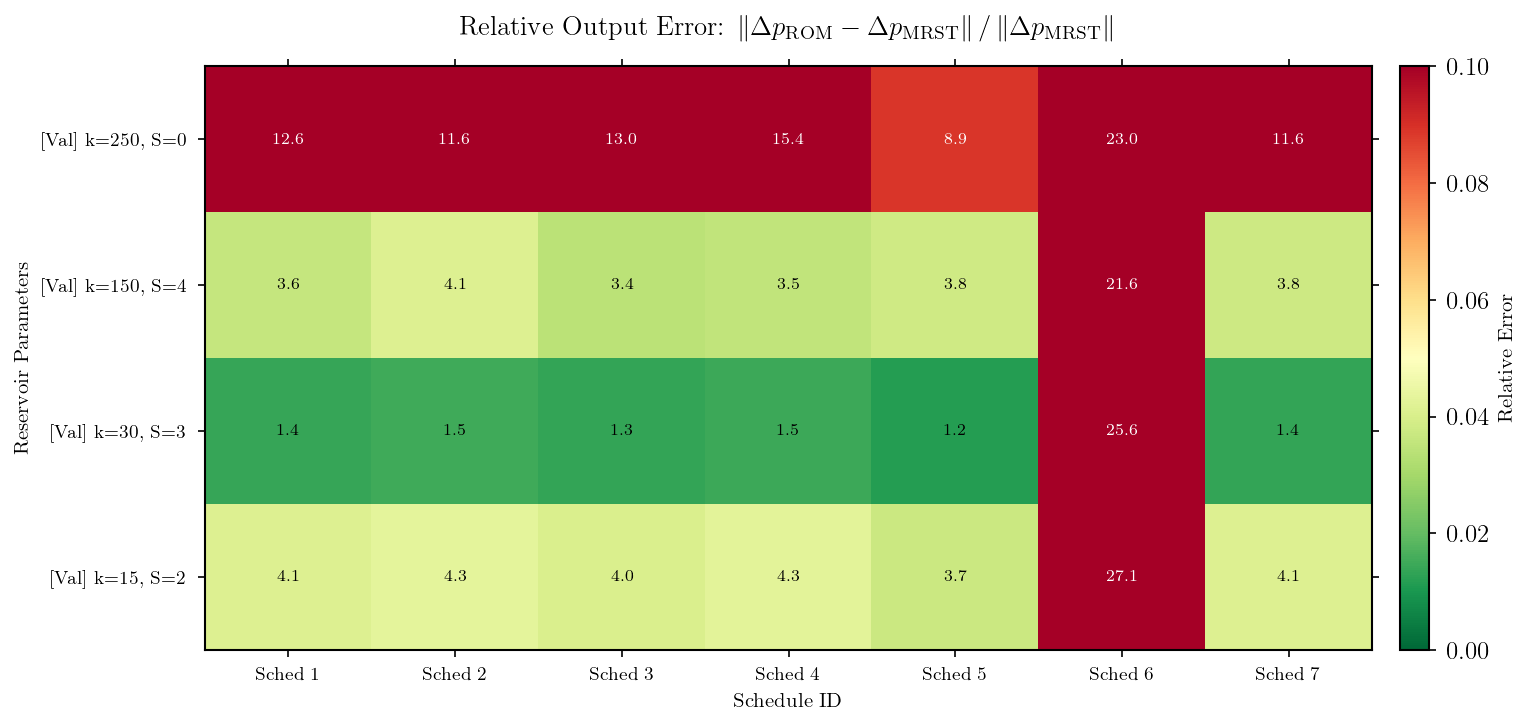

In [20]:
# ── 6.3  Heatmap: Output Error by (k,S) and Schedule ─────────────────────


fig, ax = plt.subplots(figsize=(11, 5))

# 1. Extract unique (k, S) pairs that have at least one valid error computation
valid_ks = sorted(list(set((r["k"], r["S"]) for r in val_rows if not np.isnan(r["out_err"]))))

im_data = np.full((len(valid_ks), len(SCHEDS)), np.nan)

# 2. Fill the image data array
for r in val_rows:
    if np.isnan(r["out_err"]): continue
    try:
        r_idx = valid_ks.index((r["k"], r["S"]))
        c_idx = SCHEDS.index(r["sched"])
        im_data[r_idx, c_idx] = r["out_err"]
    except ValueError:
        pass

# 3. Setup Colormap (Set missing data to light gray)
cmap = plt.cm.RdYlGn_r.copy()
cmap.set_bad(color='whitesmoke')

im = ax.imshow(im_data, aspect="auto", cmap=cmap, vmin=0, vmax=0.10, origin="lower")

# 4. Format X-Axis (Schedules)
ax.set_xticks(range(len(SCHEDS)))
ax.set_xticklabels([f"Sched {s}" for s in SCHEDS], fontsize=9)
ax.set_xlabel("Schedule ID", fontsize=10, fontweight="bold")

# 5. Format Y-Axis (Identify Train vs Validation)
y_labels = []
for k, s in valid_ks:
    # If the pair is in your training set, tag it as Train, otherwise Val
    tag = "Train" if (k, s) in VALID_PAIRS else "Val"
    y_labels.append(f"[{tag}]  k={k}, S={s}")

ax.set_yticks(range(len(valid_ks)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_ylabel("Reservoir Parameters", fontsize=10, fontweight="bold")

# 6. Title (Using raw string r"..." to prevent LaTeX \Delta parsing errors!)
ax.set_title(r"Relative Output Error: $\|\Delta p_{\rm ROM} - \Delta p_{\rm MRST}\| \,/\, \|\Delta p_{\rm MRST}\|$", 
             fontsize=13, fontweight="bold", pad=15)

# 7. Annotate the heatmap cells
for i in range(len(valid_ks)):
    for j in range(len(SCHEDS)):
        v = im_data[i, j]
        if np.isfinite(v):
            # Dynamic text color for readability
            text_col = "w" if v > 0.05 else "k"
            # Displaying as percentage makes the heatmap much easier to read!
            ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=8, color=text_col)
        else:
            # Mark missing MRST data clearly
            ax.text(j, i, "N/A", ha="center", va="center", fontsize=8, color="gray", alpha=0.6)

# 8. Colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Relative Error", fontsize=10)

plt.tight_layout()
#plt.savefig(FIG_DIR/"fig06_error_heatmap.pdf", bbox_inches="tight")
plt.show()

  fig06_vrate_validation_all_unknowns.pdf


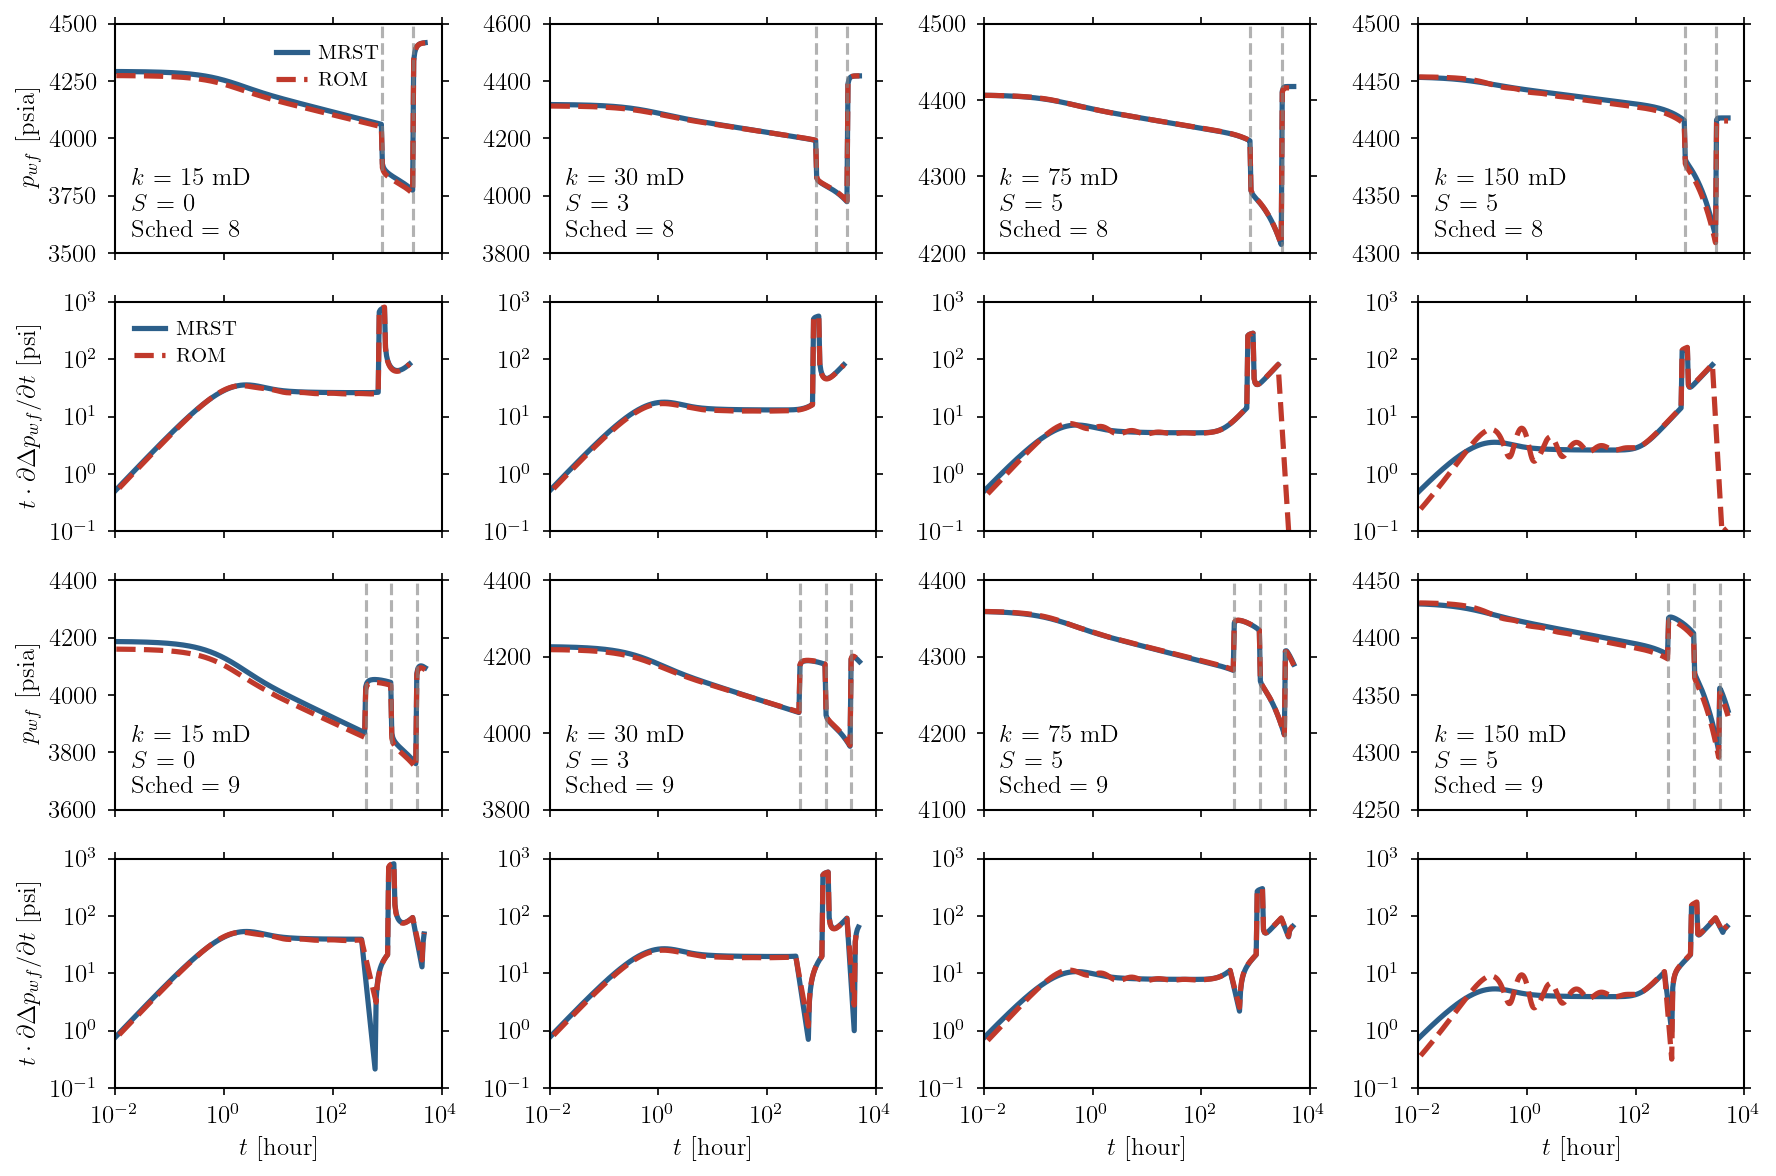

In [21]:

# ── 6.2  Comprehensive Validation:  Validation (Unseen K and s) ─────

# 1. Define explicit cases to plot: (k, S, Label)
selected_cases = [
    (15,   0, "Unseen"),
    (30,   3, "Unseen"),
    (75,   5, "Unseen"),
    (150,  5, "Unseen")
]

# Specifically target variable schedules 4 and 7
schedules_to_plot = [8, 9]

# --- CUSTOM LIMITS CONFIGURATION ---
# Dictionary keyed by Schedule ID. Each contains a list of 4 tuples (for the 4 columns).
custom_ylims_bhp = {
    8: [(3500, 4500), (3800, 4600), (4200, 4500), (4300, 4500)], # Limits for Sched 4
    9: [(3600, 4400), (3800, 4400), (4100, 4400), (4250, 4450)]  # Limits for Sched 7
}

custom_ylims_der = {
    8: [(0.1, 1000), (0.1, 1000), (0.1, 1000), (0.1, 1000)], # Limits for Sched 4
    9: [(0.1, 1000), (0.1, 1000), (0.1, 1000), (0.1, 1000)]  # Limits for Sched 7
}
# -----------------------------------

# Create a 4x4 grid (sharex=True keeps the x-axis labels clean)
fig, axes = plt.subplots(4, 4, figsize=(12, 8), sharex=True)

for col, (k_v, s_v, c_label) in enumerate(selected_cases):
    
    # We will plot two schedules per column (row_offset 0 = Sched 4, 1 = Sched 7)
    for row_offset, sid in enumerate(schedules_to_plot):
        
        # Calculate exactly which rows to place the BHP and Bourdet plots on
        row_bhp = row_offset * 2
        row_der = row_offset * 2 + 1
        
        ax_bhp = axes[row_bhp, col]
        ax_der = axes[row_der, col]
        
        # Find the data file (checking both Validation and Training folders)
        found = False
        for base in [VAL_DIR, TRAINING_DIR]:
            cd = base / f"k{k_v:03d}_s{s_v:02d}_sched{sid}"
            if (cd / "well_data.mat").exists():
                found = True
                break
        
        # Handle missing data gracefully
        if not found:
            ax_bhp.text(0.5, 0.5, f"Missing\nSched {sid}", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)
            ax_bhp.set_xticks([]); ax_bhp.set_yticks([])
            ax_der.axis('off')
            continue
            
        try:
            # Load Data and Query ROM
            bhp_m, t_hr, q_v_arr, _, pm = load_well_data(cd)
            bhp_r, _, _  = query_rom(k_v, s_v, t_hr, q_v_arr)
            rates, t_ch  = get_schedule_shape(pm)
            dp_m = np.clip(P_INIT - bhp_m, 1e-2, None)
            dp_r = np.clip(P_INIT - bhp_r, 1e-2, None)

            # --- BHP Plot ---
            ax_bhp.semilogx(t_hr, bhp_m, color=C_MRST, lw=2.5, label="MRST")
            ax_bhp.semilogx(t_hr, bhp_r, color=C_ROM,  lw=2.5, ls="--", label="ROM")
            
            # Rate change markers
            for tc in t_ch: 
                ax_bhp.axvline(tc, color="gray", ls="--", lw=1.5, alpha=0.6)
            
            # Replaced Title with Inset Text Box
            info_text = (f"$k$ = {k_v} mD\n"
                         f"$S$ = {s_v}\n"
                         f"Sched = {sid}")
            ax_bhp.text(0.05, 0.05, info_text, 
                        transform=ax_bhp.transAxes, 
                        fontsize=12, 
                        verticalalignment="bottom")
            
            # BHP Formatting
            if col == 0: 
                ax_bhp.set_ylabel("$p_{wf}$ [psia]", fontsize=12)
            
            ax_bhp.set_xlim([0.01, 1e4])
            
            # <-- Applied the custom BHP y-limits dynamically here -->
            ax_bhp.set_ylim(custom_ylims_bhp[sid][col]) 
            
            ax_bhp.xaxis.set_minor_locator(NullLocator())
            ax_bhp.yaxis.set_minor_locator(NullLocator())
            ax_bhp.tick_params(labelsize=12)
            
            # Legend only on the top-left BHP plot
            if col == 0 and row_offset == 0: 
                ax_bhp.legend(loc='upper center', bbox_to_anchor=(0.65, 0.99), fontsize=10, frameon=False)

            # --- Bourdet Derivative Plot ---
            tm, pm2, dm = bourdet(t_hr, dp_m, L=0.1)
            tr, pr2, dr = bourdet(t_hr, dp_r, L=0.1)
            
            if len(dm) > 2:
                ax_der.loglog(tm, dm, color=C_MRST, lw=2.5, label="MRST")
                ax_der.loglog(tr, dr, color=C_ROM,  lw=2.5, ls="--", label="ROM")
            
            # Deriv Formatting
            if col == 0: 
                ax_der.set_ylabel(r"$t \cdot \partial \Delta p_{wf} / \partial t$ [psi]", fontsize=12)
            
            if row_offset == 1: # Only put x-labels on the very bottom row
                ax_der.set_xlabel("$t$ [hour]", fontsize=12)
                
            ax_der.xaxis.set_minor_locator(NullLocator())
            ax_der.yaxis.set_minor_locator(NullLocator())
            ax_der.tick_params(labelsize=12)
            
            ax_der.set_xlim([0.01, 1e4])
            
            # <-- Applied the custom Deriv y-limits dynamically here -->
            ax_der.set_ylim(custom_ylims_der[sid][col]) 
            
            # Legend only on the top-left Deriv plot
            if col == 0 and row_offset == 0: 
                ax_der.legend(fontsize=10, frameon=False)
            
        except Exception as e:
            ax_bhp.text(0.5, 0.5, "Data Error", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)

plt.tight_layout()
sf("fig06_vrate_validation_all_unknowns.pdf")
plt.show()

In [22]:
# ── 7.2  Analytical MTR flat level vs ROM (all valid pairs) ───────────────
rta_rows = []
for k_v, s_v in VALID_PAIRS:
    kh     = k_v * H_FT
    dp_an  = 70.6 * 800.0 * MU_CP * BO / kh   # reference q = 800 STB/d
    rnp_an = dp_an / 800.0                      # psi/(STB/d)
    t_pss  = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k_v) * 0.1
    _, t_wbs, *_ = physics_screen(k_v, s_v)

    # ROM prediction with a test rate
    t_pred = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)
    q_test = np.full(N_STEPS, 800.0)
    bhp_r, _, _ = query_rom(k_v, s_v, t_pred, q_test)
    dp_r = P_INIT - bhp_r
    te_r, _ = materia
    
    
    
    
    
    
    
    
    
    
    
    
    
    _balance_time(t_pred, q_test)
    rnp_r   = rate_normalized_pressure(dp_r, q_test)
    tv, rv, dv = rnp_derivative(te_r, rnp_r)

    # MTR window
    mtr_m = (tv >= t_wbs / 24.0) & (tv <= t_pss / 24.0)
    flat_rom = float(np.median(dv[mtr_m])) if mtr_m.sum() > 3 else np.nan
    rel_e    = abs(flat_rom - rnp_an) / rnp_an * 100 if not np.isnan(flat_rom) else np.nan
    rta_rows.append(dict(k=k_v, S=s_v, rnp_an=rnp_an,
                         rnp_rom=flat_rom, rel_err_pct=rel_e))

df_rta = pd.DataFrame(rta_rows)
print("RTA Flat Level Comparison")
print("=" * 55)
print(df_rta[["k","S","rnp_an","rnp_rom","rel_err_pct"]]
      .rename(columns={"rnp_an":"Analytical","rnp_rom":"ROM","rel_err_pct":"Err(%)"})
      .to_string(index=False, float_format="{:.3f}".format))
print(f"\nMean relative error: {df_rta['rel_err_pct'].mean():.1f}%")


NameError: name 'materia' is not defined

## 8. Horner Build-up Analysis

A classical pressure build-up test is simulated using the ROM via Duhamel superposition:

1. **Drawdown phase**: produce at rate $q$ for time $t_p$.
2. **Build-up phase**: shut in ($q=0$) for time $\Delta t$.
3. **Horner plot**: $p_{ws}$ vs $\log_{10}[(t_p+\Delta t)/\Delta t]$ — linear in the MTR.

The **Horner slope** relates directly to permeability:
$$m = \frac{162.6\,q\,\mu\,B_o}{kh} \quad [\text{psi/log-cycle}]$$

The **skin factor** estimated from build-up:
$$S_{\rm est} = 1.151\left[\frac{p^*-p_{ws}(1\text{ hr})}{m} - \log_{10}\!\left(\frac{k}{\phi\mu c_t r_w^2}\right) + 3.2275\right]$$


In [23]:
# ── Corrected Horner Analysis Function ────────────────────────────────────
def horner_buildup(k_star, s_star, tp_hr, q_prod, n_prod=150, n_build=150):
    """
    Simulate drawdown + build-up using Backward Euler ROM integration.
    Returns a dict with Horner time ratios, BHP arrays, and analysis results.
    """
    t_draw  = np.logspace(np.log10(T_START), np.log10(tp_hr), n_prod)
    dt_shut = np.logspace(np.log10(T_START), np.log10(max(tp_hr*2, 100.0)), n_build)

    t_full  = np.concatenate([t_draw, tp_hr + dt_shut])
    q_full  = np.concatenate([np.full(n_prod, q_prod), np.zeros(n_build)])
    
    # Integrate over full history
    A = eval_op(A_interps, A_shape, k_star, s_star)
    B = eval_op(B_interps, B_shape, k_star, s_star)
    C = eval_op(C_interps, C_shape, k_star, s_star)
    D = eval_op(D_interps, D_shape, k_star, s_star)
    
    dt_v = np.diff(t_full, prepend=0.0); dt_v[0] = t_full[0]
    In = np.eye(N_MODES); xk = np.zeros(N_MODES)
    bhp_full = np.zeros(len(t_full))
    for j in range(len(t_full)):
        rhs = xk + dt_v[j] * B.ravel() * q_full[j]
        xk  = np.linalg.solve(In - dt_v[j]*A, rhs)
        bhp_full[j] = float(C @ xk + D * q_full[j]) + P_INIT

    # Build-up portion
    bu = t_full > tp_hr
    t_bu  = t_full[bu];  dt_bu = t_bu - tp_hr
    bhp_bu= bhp_full[bu]
    t_H   = (tp_hr + dt_bu) / dt_bu          # Horner time ratio

    # Analytical Horner slope (MTR)
    kh     = k_star * H_FT
    m_H    = 162.6 * q_prod * MU_CP * BO / kh
    t_wbs, t_pss = physics_screen(k_star, s_star)[1:3]

    # --- CRITICAL SKIN CALCULATION FIX ---
    p_wf_s = bhp_full[n_prod - 1]  # Pressure at the exact moment of shut-in
    idx1hr = np.argmin(np.abs(dt_bu - 1.0))
    p_1hr  = bhp_bu[idx1hr]
    
    log_k_phi = np.log10(k_star / (PHI * MU_CP * CT * RW_FT**2))
    S_est  = 1.151 * ((p_1hr - p_wf_s) / m_H - log_k_phi + 3.2275)

    return dict(t_full=t_full, bhp_full=bhp_full, q_full=q_full,
                dt_bu=dt_bu, bhp_bu=bhp_bu, t_H=t_H,
                m_H=m_H, S_est=S_est, p_wf_s=p_wf_s,
                t_wbs=t_wbs, t_pss=t_pss, kh=kh)

print("horner_buildup() updated with physical skin equation.")

horner_buildup() updated with physical skin equation.


  fig08_horner_buildup_blind.pdf


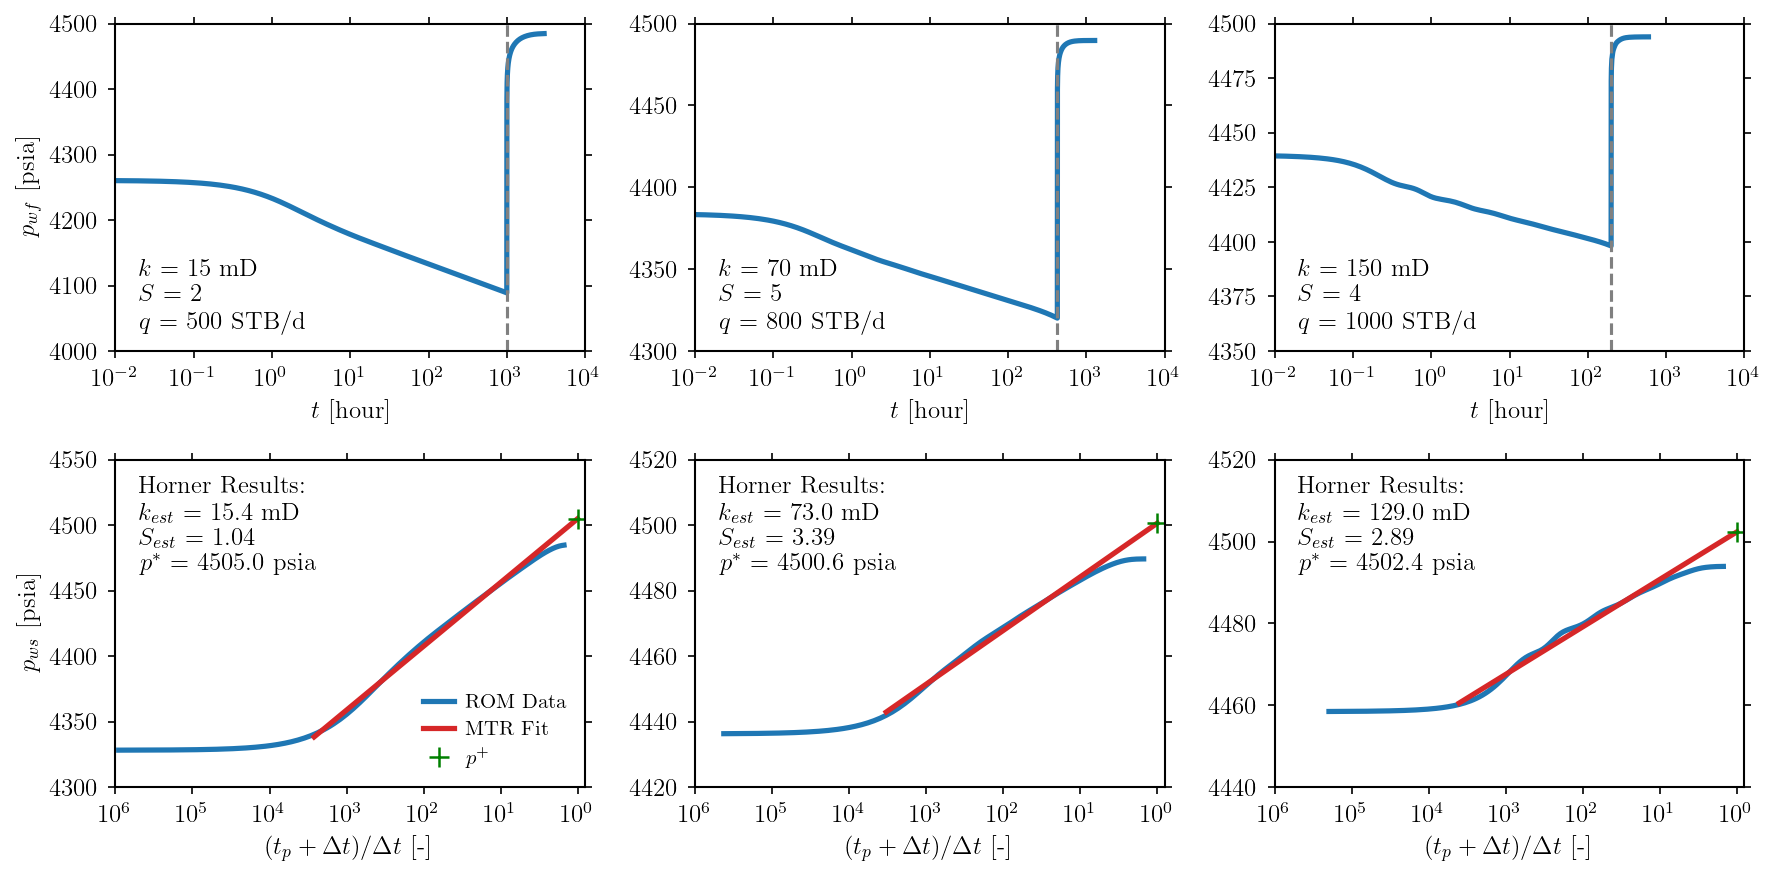

In [24]:
# ── 8.1 True Blind Validation: Horner Build-up Analysis ──────────────────────
blind_buildup_cases = [(15, 2, 500), (70, 5, 800), (150, 4, 1000)]

# --- LIMITS CONFIGURATION ---
custom_ylims_pwf = [(4000, 4500), (4300, 4500), (4350, 4500)]
custom_ylims_horner = [(4300, 4550), (4420, 4520), (4440, 4520)]
# -----------------------------------

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for col, (k_b, s_b, q_b) in enumerate(blind_buildup_cases):
    tp = min(1000.0, (PHI*MU_CP*CT*RE_FT**2) / (0.000264*k_b) * 0.5)
    res = horner_buildup(k_b, s_b, tp_hr=tp, q_prod=q_b)
    m_an = res["m_H"]

    # ── Top Row: Full Test History ───────────────────────────────────────
    ax_t = axes[0, col]
    ax_t.semilogx(res["t_full"], res["bhp_full"], color='C0', lw=2.5)
    ax_t.axvline(tp, color="gray", ls="--", lw=1.5)

    ax_t.set_xlabel("$t$ [hour]", fontsize=12)
    if col == 0: 
        ax_t.set_ylabel("$p_{wf}$ [psia]", fontsize=12)
    
    # MODIFIED: Added the flow rate (q) to the inset text
    info_text_t = (f"$k$ = {k_b} mD\n"
                   f"$S$ = {s_b}\n"
                   f"$q$ = {q_b} STB/d")
    ax_t.text(0.05, 0.05, info_text_t, 
              transform=ax_t.transAxes, 
              fontsize=12, 
              verticalalignment="bottom")

    ax_t.xaxis.set_minor_locator(NullLocator())
    ax_t.yaxis.set_minor_locator(NullLocator())
    ax_t.tick_params(labelsize=12)
    ax_t.set_ylim(custom_ylims_pwf[col])
    ax_t.set_xlim(1e-2, 1e4)
    
    if col == 0: 
        ax_t.legend(fontsize=10, frameon=False, loc="lower left", bbox_to_anchor=(0.0, 0.35))

    # ── Bottom Row: Horner Plot ──────────────────────────────────────────
    ax_h = axes[1, col]
    t_H = res["t_H"]
    bhp_H = res["bhp_bu"]

    # MODIFIED: Changed to a line plot ("-") and sliced [1:] to neglect the initial low shock point
    ax_h.semilogx(t_H[1:], bhp_H[1:], "-", color='C0', lw=2.5, label="ROM Data")

    dt_ = res["dt_bu"]
    mtr_h = (dt_ >= res["t_wbs"]) & (dt_ <= res["t_pss"])

    if mtr_h.sum() > 3:
        log_tH_mtr = np.log10(t_H[mtr_h])
        bhp_mtr    = bhp_H[mtr_h]
        coeffs     = np.polyfit(log_tH_mtr, bhp_mtr, 1)
        m_rom      = -coeffs[0]
        
        # Extrapolate p* directly at Horner Time = 1 (where log10(1) = 0)
        p_star_ext = coeffs[1] 
        
        # Calculate ROM estimated permeability from the slope ratio
        k_est = k_b * (m_an / m_rom)

        # Plot the MTR line EXTENDED to t_H = 1
        t_H_fit = np.logspace(0, np.log10(t_H[mtr_h].max()), 100)
        ax_h.semilogx(t_H_fit, np.polyval(coeffs, np.log10(t_H_fit)),
                      color='C3', lw=2.5, label=f"MTR Fit")

        # Mark the extrapolated p* point
        ax_h.plot(1.0, p_star_ext, "+", color='green', ms=10, mec="green", mew=1.2, label=f"$p^+$")

        # MODIFIED: Specifically list the Horner analysis results
        info_text_h = (f"Horner Results:\n"
                       f"$k_{{est}}$ = {k_est:.1f} mD\n"
                       f"$S_{{est}}$ = {res['S_est']:.2f}\n"
                       f"$p^*$ = {p_star_ext:.1f} psia")
        ax_h.text(0.05, 0.95, info_text_h, 
                  transform=ax_h.transAxes, 
                  fontsize=12, 
                  verticalalignment="top")
    else:
        ax_h.text(0.05, 0.95, "Insufficient MTR Data", 
                  transform=ax_h.transAxes, 
                  fontsize=12, 
                  verticalalignment="top")

    # Invert x-axis (Horner time decreases to the right)
    ax_h.invert_xaxis()
    ax_h.set_xlabel(r"$(t_p+\Delta t)/\Delta t$ [-]", fontsize=12)
    if col == 0: 
        ax_h.set_ylabel("$p_{ws}$ [psia]", fontsize=12)
        
    # MODIFIED: Apply the custom y-limits array for the Horner plot
    ax_h.set_ylim(custom_ylims_horner[col])
    ax_h.set_xlim(1e6, 1e0-0.2)
        
    ax_h.xaxis.set_minor_locator(NullLocator())
    ax_h.yaxis.set_minor_locator(NullLocator())
    ax_h.tick_params(labelsize=12)
    
    if col == 0:
        ax_h.legend(fontsize=10, frameon=False, loc="lower right")

plt.tight_layout()
sf("fig08_horner_buildup_blind.pdf")
plt.show()

## 9. Deconvolution Module

**Deconvolution** recovers the unit-step response $g(t)$ from a variable-rate pressure record
$\Delta p(t)$ and rate history $q(t)$ by inverting the convolution:

$$\Delta p(t_i) = \sum_{j=0}^{i} \frac{\Delta q_j}{q_{\rm ref}}\,g(t_i - t_j)$$

This is rewritten as a linear system $\mathbf{L}\mathbf{g} = \boldsymbol{\Delta p}$,
where $\mathbf{L}$ is a lower-triangular Toeplitz-like matrix.
Because this problem is ill-posed, **Tikhonov regularisation** (order 2) is applied:

$$\min_{\mathbf{g}\geq 0}\;\|\mathbf{L}\mathbf{g}-\boldsymbol{\Delta p}\|_2^2 + \lambda\|\mathbf{D}_2\mathbf{g}\|_2^2$$

where $\mathbf{D}_2$ is the second-difference matrix (penalises curvature of $g$).

**Application**: Deconvolution can extend the apparent test duration beyond the individual
drawdown periods and reveal features (e.g. boundary effects) hidden in variable-rate data.


  ch7_add_multischedule_deconv.pdf


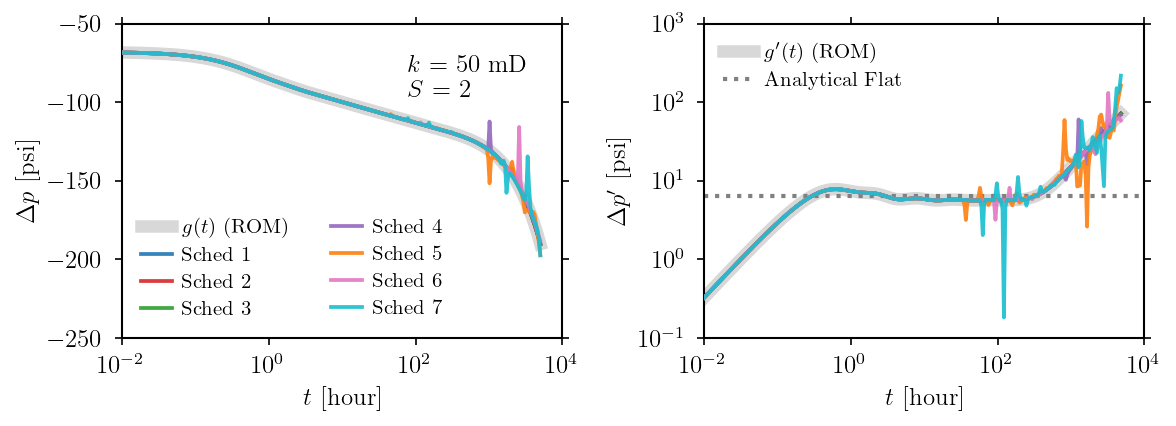

In [26]:


# ── 9.1  Rigorous Log-Grid Deconvolution Functions ────────────────────────────

def build_convolution_matrix(t_hr, q_vec, q_ref):
    N = len(t_hr)
    dq = np.diff(q_vec, prepend=0.0)
    L = np.zeros((N, N))
    
    change_idx = np.where(np.abs(dq) > 1e-4)[0]
    
    for i in range(N):
        for j in change_idx:
            if j > i: 
                continue 
            
            t_onset = t_hr[j] if j > 0 else 0.0
            t_shift = t_hr[i] - t_onset
            
            if t_shift <= t_hr[0]:
                L[i, 0] += dq[j] / q_ref
                continue
                
            k = np.searchsorted(t_hr, t_shift)
            
            if k >= N:
                L[i, N-1] += dq[j] / q_ref
            else:
                t_left, t_right = t_hr[k-1], t_hr[k]
                w = (t_shift - t_left) / (t_right - t_left)
                L[i, k-1] += (dq[j] / q_ref) * (1 - w)
                L[i, k]   += (dq[j] / q_ref) * w
                
    return L


def deconvolve(t_hr, dp_psi, q_vec, lam=1e-1, q_ref=500.0, n_iter=3):
    N = len(t_hr)
    L = build_convolution_matrix(t_hr, q_vec, q_ref)
    D2 = np.diff(np.eye(N), n=2, axis=0)

    lam_k = lam
    for _ in range(n_iter):
        A_aug = np.vstack([L, np.sqrt(lam_k) * D2])
        b_aug = np.concatenate([dp_psi, np.zeros(N-2)])
        
        g, *_ = np.linalg.lstsq(A_aug, b_aug, rcond=None)
        g = np.maximum(g, 0.0) 
        
        resid = np.linalg.norm(L @ g - dp_psi)**2
        lam_k = max(lam * resid / (N + 1e-9), 1e-5)

    return g


# ── 9.2  Multi-Schedule Deconvolution: Consistency Proof ──────────────────────

k_mc, s_mc  = 50, 2
q_ref_mc    = 500.0

# 1. Generate Ground Truth Unit Step Response from ROM
t_ref_mc     = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)
h_ref_raw, _ = unit_step_response(k_mc, s_mc, t_ref_mc, q_ref=q_ref_mc)
h_true       = np.abs(h_ref_raw) 

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Panel A: Ground Truth h(t)
# MODIFIED: Plotted as negative, and label changed to h(t)
axes[0].semilogx(t_ref_mc, -h_true, color='gray', lw=6.0, alpha=0.3, label="$g(t)$ (ROM)", zorder=1)

# Panel B: Ground Truth Derivative h'(t)
dp_h = np.clip(h_true, 1e-2, None)
th, _, dh = bourdet(t_ref_mc, dp_h)
axes[1].loglog(th, dh, color='gray', lw=6.0, alpha=0.3, label="$g'(t)$ (ROM)", zorder=1)

# 2. Iterate through ALL schedules
contrast_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#e377c2', '#17becf', '#8c564b', '#bcbd22']

for idx, sid in enumerate(SCHEDS):
    cd_mc = next((base / f"k{k_mc:03d}_s{s_mc:02d}_sched{sid}" for base in [VAL_DIR, TRAINING_DIR] 
                  if (base / f"k{k_mc:03d}_s{s_mc:02d}_sched{sid}"/"well_data.mat").exists()), None)
    
    if cd_mc is None: continue
    
    try:
        _, t_j, q_j, _, _ = load_well_data(cd_mc)
        bhp_j, _, _ = query_rom(k_mc, s_mc, t_j, q_j)
        dp_j = np.clip(P_INIT - bhp_j, 1e-2, None)
        
        g_j  = deconvolve(t_j, dp_j, q_j, lam=1e-1, q_ref=q_ref_mc)
        
        col = contrast_colors[idx % len(contrast_colors)]
        
        # Panel A: Plot recovered g(t) (Foreground)
        # MODIFIED: Plotted as negative
        axes[0].semilogx(t_j, -g_j, color=col, lw=1.8, alpha=0.9, label=f"Sched {sid}", zorder=5)
        
        # Panel B: Plot recovered derivative g'(t) (Foreground)
        dp_g = np.clip(g_j, 1e-2, None)
        tg, _, dg = bourdet(t_j, dp_g)
        axes[1].loglog(tg, dg, color=col, lw=1.8, alpha=0.9, zorder=5)
                       
    except Exception as e:
        print(f"Error on Sched {sid}: {e}")

# --- Aesthetics: Panel A (Pressure Signature) ---
axes[0].set_xlabel("$t$ [hour]", fontsize=12)
# MODIFIED: Changed y-axis label to Delta p
axes[0].set_ylabel(r"$\Delta p$ [psi]", fontsize=12)

info_text = (f"$k$ = {k_mc} mD\n"
             f"$S$ = {s_mc}")
axes[0].text(0.65, 0.75, info_text, 
             transform=axes[0].transAxes, 
             fontsize=12, 
             verticalalignment="bottom")

axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_minor_locator(NullLocator())
axes[0].tick_params(labelsize=12)
axes[0].set_xlim(1e-2, 1e4)

# MODIFIED: Flipped the limits to be negative to match the data
axes[0].set_ylim(-250, -50) 
axes[0].legend(fontsize=10, frameon=False, loc="lower left", ncol=2)

# --- Aesthetics: Panel B (Log-Log Derivative Signature) ---
kh_mc   = k_mc * H_FT
dp_prim = 70.6 * q_ref_mc * MU_CP * BO / kh_mc
axes[1].axhline(dp_prim, color="gray", ls=":", lw=2.0, label="Analytical Flat", zorder=0)

axes[1].set_xlabel("$t$ [hour]", fontsize=12)
axes[1].set_ylabel(r"$\Delta p'$ [psi]", fontsize=12)

axes[1].xaxis.set_minor_locator(NullLocator())
axes[1].yaxis.set_minor_locator(NullLocator())
axes[1].tick_params(labelsize=12)
axes[1].set_xlim(1e-2, 1e4)
axes[1].set_ylim(1e-1,1e3)
axes[1].legend(fontsize=10, frameon=False, loc="upper left")

plt.tight_layout()
sf("ch7_add_multischedule_deconv.pdf")
plt.show()